In [2]:
# ============================================================
# RESET UTILITIES FOR ITERATION 6
# ============================================================

import os
import json
import glob
import shutil

# Iteration 6 paths
DATA_DIR = "/home/azureuser/cloudfiles/code/Users/M02555/Datasets/By_Country/"
EMBEDDINGS_BASE_DIR = "/home/azureuser/cloudfiles/code/Users/M02555/Datasets/Embeddings/_iteration_6"
RESULTS_DIR = "/home/azureuser/cloudfiles/code/Users/M02555/Results/_iteration_6"
CHECKPOINT_FILE = "/home/azureuser/cloudfiles/code/Users/M02555/_Iterations/_iteration_6/checkpoint.json"

def reset_checkpoint():
    """Delete checkpoint to restart from beginning"""
    if os.path.exists(CHECKPOINT_FILE):
        os.remove(CHECKPOINT_FILE)
        print("[OK] Checkpoint cleared - will restart from beginning")
    else:
        print("[INFO] No checkpoint found - already clean")

def view_progress():
    """View current progress"""
    if os.path.exists(CHECKPOINT_FILE):
        with open(CHECKPOINT_FILE, 'r') as f:
            data = json.load(f)
            processed = data['processed']
            print(f"\n{'='*60}")
            print(f"ITERATION 6 PROGRESS: {len(processed)} combinations processed")
            print(f"{'='*60}")
            print("\nCompleted:")
            for item in processed:
                if isinstance(item, (list, tuple)) and len(item) >= 2:
                    model, dataset = item[0], item[1]
                    print(f"  [x] {model:45s} -> {dataset}")
                else:
                    print(f"  [x] {item}")
    else:
        print("[INFO] No checkpoint found - no progress yet")

def reset_embeddings():
    """Delete all generated embeddings for iteration 6"""
    if os.path.exists(EMBEDDINGS_BASE_DIR):
        response = input(f"[WARNING] Delete ALL embeddings in {EMBEDDINGS_BASE_DIR}? (yes/no): ")
        if response.lower() == 'yes':
            shutil.rmtree(EMBEDDINGS_BASE_DIR)
            os.makedirs(EMBEDDINGS_BASE_DIR)
            print("[OK] All iteration 6 embeddings deleted")
        else:
            print("[CANCELLED]")
    else:
        print("[INFO] Embeddings directory doesn't exist")

def reset_results():
    """Delete all results for iteration 6"""
    if os.path.exists(RESULTS_DIR):
        response = input(f"[WARNING] Delete ALL results in {RESULTS_DIR}? (yes/no): ")
        if response.lower() == 'yes':
            for file in glob.glob(os.path.join(RESULTS_DIR, '*')):
                os.remove(file)
            print("[OK] All iteration 6 results deleted")
        else:
            print("[CANCELLED]")
    else:
        print("[INFO] Results directory doesn't exist")

def full_reset():
    """Complete reset - checkpoint, embeddings, and results"""
    print("\n" + "="*60)
    print("[WARNING] FULL RESET - ITERATION 6")
    print("="*60)
    response = input("This will delete EVERYTHING (checkpoint, embeddings, results). Continue? (yes/no): ")
    if response.lower() == 'yes':
        reset_checkpoint()
        if os.path.exists(EMBEDDINGS_BASE_DIR):
            shutil.rmtree(EMBEDDINGS_BASE_DIR)
            os.makedirs(EMBEDDINGS_BASE_DIR)
            print("[OK] Embeddings deleted")
        if os.path.exists(RESULTS_DIR):
            for file in glob.glob(os.path.join(RESULTS_DIR, '*')):
                os.remove(file)
            print("[OK] Results deleted")
        print("\n[OK] Full reset complete - Ready for fresh start")
    else:
        print("[CANCELLED]")

def remove_specific_model(model_key):
    """Remove specific model from checkpoint to reprocess it"""
    if os.path.exists(CHECKPOINT_FILE):
        with open(CHECKPOINT_FILE, 'r') as f:
            data = json.load(f)
            processed = data['processed']
        
        original_count = len(processed)
        processed = [item for item in processed if item[0] != model_key]
        removed_count = original_count - len(processed)
        
        with open(CHECKPOINT_FILE, 'w') as f:
            json.dump({'processed': processed}, f)
        
        print(f"[OK] Removed {removed_count} combinations for model: {model_key}")
        print(f"Remaining: {len(processed)} combinations")
    else:
        print("[INFO] No checkpoint found")

def remove_specific_dataset(dataset_name):
    """Remove specific dataset from checkpoint to reprocess it"""
    if os.path.exists(CHECKPOINT_FILE):
        with open(CHECKPOINT_FILE, 'r') as f:
            data = json.load(f)
            processed = data['processed']
        
        original_count = len(processed)
        processed = [item for item in processed if item[1] != dataset_name]
        removed_count = original_count - len(processed)
        
        with open(CHECKPOINT_FILE, 'w') as f:
            json.dump({'processed': processed}, f)
        
        print(f"[OK] Removed {removed_count} combinations for dataset: {dataset_name}")
        print(f"Remaining: {len(processed)} combinations")
    else:
        print("[INFO] No checkpoint found")

def complete_rerun():
    """Simple one-command complete restart for iteration 6"""
    print("\n" + "="*60)
    print("COMPLETE RERUN - ITERATION 6")
    print("="*60)
    print("This will:")
    print("  1. Clear checkpoint file")
    print("  2. Delete all embeddings")
    print("  3. Delete all results")
    print("  4. Start fresh from beginning")
    print("="*60)
    response = input("\nProceed with complete rerun? (yes/no): ")
    if response.lower() == 'yes':
        # Clear checkpoint
        if os.path.exists(CHECKPOINT_FILE):
            os.remove(CHECKPOINT_FILE)
            print("[OK] Checkpoint cleared")
        
        # Clear embeddings
        if os.path.exists(EMBEDDINGS_BASE_DIR):
            shutil.rmtree(EMBEDDINGS_BASE_DIR)
            os.makedirs(EMBEDDINGS_BASE_DIR)
            print("[OK] Embeddings deleted")
        
        # Clear results
        if os.path.exists(RESULTS_DIR):
            for file in glob.glob(os.path.join(RESULTS_DIR, '*')):
                os.remove(file)
            print("[OK] Results deleted")
        
        print("\n" + "="*60)
        print("[READY] COMPLETE RERUN READY - ITERATION 6")
        print("="*60)
        print("Now run the main pipeline cell to start fresh!")
        print("="*60)
    else:
        print("[CANCELLED]")

def show_disk_usage():
    """Show disk usage for iteration 6 files"""
    print("\n" + "="*60)
    print("DISK USAGE - ITERATION 6")
    print("="*60)
    
    # Embeddings size
    if os.path.exists(EMBEDDINGS_BASE_DIR):
        total_size = 0
        file_count = 0
        for root, dirs, files in os.walk(EMBEDDINGS_BASE_DIR):
            for f in files:
                fp = os.path.join(root, f)
                total_size += os.path.getsize(fp)
                file_count += 1
        print(f"Embeddings: {total_size / 1024**3:.2f} GB ({file_count} files)")
    else:
        print("Embeddings: 0 GB (directory doesn't exist)")
    
    # Results size
    if os.path.exists(RESULTS_DIR):
        total_size = sum(os.path.getsize(os.path.join(RESULTS_DIR, f)) 
                        for f in os.listdir(RESULTS_DIR) if os.path.isfile(os.path.join(RESULTS_DIR, f)))
        file_count = len([f for f in os.listdir(RESULTS_DIR) if os.path.isfile(os.path.join(RESULTS_DIR, f))])
        print(f"Results: {total_size / 1024**2:.2f} MB ({file_count} files)")
    else:
        print("Results: 0 MB (directory doesn't exist)")
    
    print("="*60)

def list_models_in_checkpoint():
    """List all models and their dataset counts in checkpoint"""
    if os.path.exists(CHECKPOINT_FILE):
        with open(CHECKPOINT_FILE, 'r') as f:
            data = json.load(f)
            processed = data['processed']
        
        model_counts = {}
        for item in processed:
            if isinstance(item, (list, tuple)) and len(item) >= 2:
                model = item[0]
                model_counts[model] = model_counts.get(model, 0) + 1
        
        print(f"\n{'='*60}")
        print(f"MODELS IN CHECKPOINT - ITERATION 6")
        print(f"{'='*60}")
        for model, count in sorted(model_counts.items()):
            print(f"  {model:45s}: {count} datasets")
        print(f"{'='*60}")
        print(f"Total: {len(processed)} combinations")
    else:
        print("[INFO] No checkpoint found")

def list_datasets_in_checkpoint():
    """List all datasets and their model counts in checkpoint"""
    if os.path.exists(CHECKPOINT_FILE):
        with open(CHECKPOINT_FILE, 'r') as f:
            data = json.load(f)
            processed = data['processed']
        
        dataset_counts = {}
        for item in processed:
            if isinstance(item, (list, tuple)) and len(item) >= 2:
                dataset = item[1]
                dataset_counts[dataset] = dataset_counts.get(dataset, 0) + 1
        
        print(f"\n{'='*60}")
        print(f"DATASETS IN CHECKPOINT - ITERATION 6")
        print(f"{'='*60}")
        for dataset, count in sorted(dataset_counts.items()):
            print(f"  {dataset:25s}: {count} models")
        print(f"{'='*60}")
        print(f"Total: {len(processed)} combinations")
    else:
        print("[INFO] No checkpoint found")

# ============================================================
# Quick Commands - Uncomment the one you want to run
# ============================================================

# View current progress
view_progress()

# Show disk usage
# show_disk_usage()

# List models in checkpoint
# list_models_in_checkpoint()

# List datasets in checkpoint
# list_datasets_in_checkpoint()

# To reset just checkpoint (keeps embeddings/results):
# reset_checkpoint()

# To remove a specific model (e.g., to reprocess it):
# remove_specific_model('intfloat/multilingual-e5-large-instruct')

# To remove a specific dataset (e.g., to reprocess it):
# remove_specific_dataset('sweden')

# To do a complete rerun:
# complete_rerun()

print("\n" + "="*60)
print("RESTART UTILITIES LOADED - ITERATION 6")
print("="*60)
print("Available functions:")
print("  view_progress()              - See what's completed")
print("  show_disk_usage()            - Check disk usage")
print("  list_models_in_checkpoint()  - List models and counts")
print("  list_datasets_in_checkpoint()- List datasets and counts")
print("  reset_checkpoint()           - Clear checkpoint only")
print("  remove_specific_model(name)  - Remove model from checkpoint")
print("  remove_specific_dataset(name)- Remove dataset from checkpoint")
print("  reset_embeddings()           - Delete all embeddings")
print("  reset_results()              - Delete all results")
print("  complete_rerun()             - COMPLETE RESTART (everything)")
print("="*60)
print("\nTIP: To completely restart everything, run: complete_rerun()")


ITERATION 6 PROGRESS: 6 combinations processed

Completed:
  [x] English                                       -> paraphrase-multilingual-MiniLM-L12-v2
  [x] Germany                                       -> paraphrase-multilingual-MiniLM-L12-v2
  [x] UK                                            -> paraphrase-multilingual-MiniLM-L12-v2
  [x] Netherlands                                   -> paraphrase-multilingual-MiniLM-L12-v2
  [x] English                                       -> bert-base-multilingual-uncased
  [x] Sweden                                        -> paraphrase-multilingual-MiniLM-L12-v2

RESTART UTILITIES LOADED - ITERATION 6
Available functions:
  view_progress()              - See what's completed
  show_disk_usage()            - Check disk usage
  list_models_in_checkpoint()  - List models and counts
  list_datasets_in_checkpoint()- List datasets and counts
  reset_checkpoint()           - Clear checkpoint only
  remove_specific_model(name)  - Remove model from chec

In [3]:
complete_rerun()


COMPLETE RERUN - ITERATION 6
This will:
  1. Clear checkpoint file
  2. Delete all embeddings
  3. Delete all results
  4. Start fresh from beginning
[OK] Checkpoint cleared
[OK] Embeddings deleted
[OK] Results deleted

[READY] COMPLETE RERUN READY - ITERATION 6
Now run the main pipeline cell to start fresh!


In [4]:
# ============================================================
# ITERATION 6 - LANGUAGE-AWARE UNDERSAMPLING + STRONG REGULARIZATION
# ============================================================
# Goal: Achieve 98% Macro F1-score through:
# 1. LANGUAGE-AWARE Undersampling (1:1 ratio per language)
# 2. Select LONGEST text within each language (most informative)
# 3. NO synthetic data (100% real data)
# 4. Strong regularization to prevent overfitting
# 5. Optimized cost-sensitive learning
# 6. Threshold optimization for PS recall
# ============================================================

import pandas as pd
import numpy as np
import os
import re
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, 
    f1_score, precision_recall_fscore_support,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
)
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModel
import torch
from tqdm import tqdm
import pickle
import glob
import gc
import json
import time
import warnings
warnings.filterwarnings('ignore')

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    print("XGBoost not available. Install with: pip install xgboost")
    XGBOOST_AVAILABLE = False

try:
    from lightgbm import LGBMClassifier
    LIGHTGBM_AVAILABLE = True
except ImportError:
    print("LightGBM not available. Install with: pip install lightgbm")
    LIGHTGBM_AVAILABLE = False

try:
    from imblearn.under_sampling import RandomUnderSampler
    IMBLEARN_AVAILABLE = True
except ImportError:
    print("imbalanced-learn not available. Install with: pip install imbalanced-learn")
    IMBLEARN_AVAILABLE = False

print("\n" + "#"*80)
print("ITERATION 6: LANGUAGE-AWARE SMART UNDERSAMPLING + STRONG REGULARIZATION")
print("Target: 98% Macro F1-Score")
print("Strategy: Language-Balanced Length-Based Undersampling (1:1) + Strong Regularization")
print("#"*80)

# ============================================================
# CONFIGURATION
# ============================================================

DATA_DIR = "/home/azureuser/cloudfiles/code/Users/M02555/Datasets/By_Country/"
EMBEDDINGS_BASE_DIR = "/home/azureuser/cloudfiles/code/Users/M02555/Datasets/Embeddings/_iteration_6"
RESULTS_DIR = "/home/azureuser/cloudfiles/code/Users/M02555/Results/_iteration_6"
CHECKPOINT_FILE = "/home/azureuser/cloudfiles/code/Users/M02555/_Iterations/_iteration_6/checkpoint.json"

os.makedirs(EMBEDDINGS_BASE_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(os.path.dirname(CHECKPOINT_FILE), exist_ok=True)

# ITERATION 6 CONFIGURATION
CONFIG = {
    # Embedding strategy
    'pooling_strategy': 'mean',
    'text_preprocessing': True,
    'use_feature_scaling': True,
    
    # LANGUAGE-AWARE SMART UNDERSAMPLING ONLY - NO SMOTE
    'use_smote': False,
    'smote_strategy': None,
    'use_undersampling': True,
    'undersample_strategy': 1.0,  # 1:1 ratio per language
    'undersample_method': 'language_aware_length_based',  # NEW
    'combine_smote_tomek': False,
    
    # STRONG REGULARIZATION
    'strong_regularization': True,
    
    # Classifier optimization
    'hyperparameter_tuning': True,
    'use_ensemble': True,
    'classifiers': ['svm', 'xgboost', 'lightgbm', 'random_forest', 'ensemble'],
    'cv_folds': 5,
    
    # Threshold optimization
    'optimize_threshold': True,
    'target_ps_recall': 0.95,
    'target_macro_f1': 0.98,
    
    # Aggressive class weights
    'aggressive_class_weights': True,
    'ps_weight_multiplier': 10,
}

MODELS = {
    'bert-base-multilingual-uncased': 'google-bert/bert-base-multilingual-uncased',
    'xlm-roberta-base': 'xlm-roberta-base', 
    'paraphrase-multilingual-mpnet-base-v2': 'sentence-transformers/paraphrase-multilingual-mpnet-base-v2',
    'paraphrase-multilingual-MiniLM-L12-v2': 'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2',
    'snowflake-arctic-embed-l-v2.0': 'snowflake/snowflake-arctic-embed-l-v2.0',
    'labse-gguf': 'ChristianAzinn/labse-gguf',
    'upskyy/bge-m3-korean': 'upskyy/bge-m3-korean',
    'intfloat/multilingual-e5-large-instruct': 'intfloat/multilingual-e5-large-instruct',
    'efederici/e5-base-multilingual-4096': 'efederici/e5-base-multilingual-4096',
}

SKIP_DATASETS = [
    'RW_ACTUALS_Hungary.csv',
    'RW_ACTUALS_International.csv',
    'RW_ACTUALS_Russia.csv',
    'RW_ACTUALS_UAE.csv'
]

BATCH_SIZE = 8
MAX_SAMPLES_SVM = 100000

# CONFIG VALIDATION
def validate_config():
    """Validate CONFIG settings for consistency"""
    issues = []
    
    if CONFIG.get('target_macro_f1', 0.98) > 1.0 or CONFIG.get('target_macro_f1', 0.98) < 0.0:
        issues.append("target_macro_f1 must be between 0 and 1")
    
    if CONFIG.get('target_ps_recall', 0.95) > 1.0 or CONFIG.get('target_ps_recall', 0.95) < 0.0:
        issues.append("target_ps_recall must be between 0 and 1")
    
    if 'target_macro_f1' not in CONFIG:
        issues.append("WARNING: 'target_macro_f1' not in CONFIG, adding default 0.98")
        CONFIG['target_macro_f1'] = 0.98
    
    if issues:
        print(f"\n{'='*80}")
        print("CONFIG VALIDATION WARNINGS:")
        print(f"{'='*80}")
        for issue in issues:
            print(f"   {issue}")
        print(f"{'='*80}\n")
        
        if any('must be between' in issue for issue in issues):
            raise ValueError("CONFIG contains invalid values. Please fix and re-run.")
    else:
        print(f"\n CONFIG validation passed")

validate_config()

# PERFORMANCE COLOR HELPER
def get_performance_color(value, threshold=None):
    """Return color based on performance threshold"""
    if threshold is None:
        threshold = CONFIG.get('target_macro_f1', 0.98)
    
    if value >= threshold:
        return 'green'
    elif value >= threshold - 0.05:
        return 'steelblue'
    else:
        return 'coral'

print(f"\nITERATION 6 CONFIGURATION:")
print(f"   |- Pooling Strategy: {CONFIG['pooling_strategy']}")
print(f"   |- SMOTE Strategy: DISABLED")
print(f"   |- Undersampling: {CONFIG['use_undersampling']} (Strategy: {CONFIG['undersample_strategy']} = 1:1 per language)")
print(f"   |- Undersampling Method: LANGUAGE-AWARE + LENGTH-BASED")
print(f"   |- Strong Regularization: {CONFIG['strong_regularization']}")
print(f"   |- Threshold Optimization: {CONFIG['optimize_threshold']}")
print(f"   |- Target Macro F1: >= {CONFIG['target_macro_f1']}")
print(f"   |- Target PS Recall: >= {CONFIG['target_ps_recall']}")
print(f"   |- PS Weight Multiplier: {CONFIG['ps_weight_multiplier']}x")
print(f"   |- Selection Quality: HIGHEST (language-balanced + longest text)")

# ============================================================
# TEXT PREPROCESSING & CHECKPOINT FUNCTIONS
# ============================================================

def advanced_text_preprocessing(text):
    """Enhanced text preprocessing"""
    if pd.isna(text):
        return ""
    
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'[^a-zA-Z0-9\s\.]', ' ', text)
    text = ' '.join(text.split())
    
    return text

def save_checkpoint(processed_items):
    with open(CHECKPOINT_FILE, 'w') as f:
        json.dump({'processed': list(processed_items)}, f)
    print(f"Checkpoint saved: {len(processed_items)} combinations processed")

def load_checkpoint():
    if os.path.exists(CHECKPOINT_FILE):
        with open(CHECKPOINT_FILE, 'r') as f:
            return set(tuple(item) for item in json.load(f)['processed'])
    return set()

# Note: reset_checkpoint() is defined in Cell 2 (Reset Utilities)

# ============================================================
# ENHANCED EMBEDDING GENERATION
# ============================================================

def get_enhanced_embeddings(texts, tokenizer, model, pooling='mean', max_length=512, batch_size=8):
    """Generate embeddings with advanced pooling strategies"""
    embeddings = []
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model = model.to(device)
    model.eval()
    
    print(f"Using device: {device}")
    print(f"Pooling strategy: {pooling}")
    
    for i in tqdm(range(0, len(texts), batch_size), desc="Generating embeddings"):
        batch_texts = texts[i:i + batch_size]
        
        inputs = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        ).to(device)
        
        with torch.no_grad():
            outputs = model(**inputs)
            
            if pooling == 'cls':
                batch_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            elif pooling == 'mean':
                attention_mask = inputs['attention_mask']
                token_embeddings = outputs.last_hidden_state
                input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
                sum_embeddings = torch.sum(token_embeddings * input_mask_expanded, 1)
                sum_mask = torch.clamp(input_mask_expanded.sum(1), min=1e-9)
                batch_embeddings = (sum_embeddings / sum_mask).cpu().numpy()
            elif pooling == 'max':
                token_embeddings = outputs.last_hidden_state
                batch_embeddings = torch.max(token_embeddings, dim=1)[0].cpu().numpy()
            else:
                raise ValueError(f"Unknown pooling strategy: {pooling}")
            
            embeddings.extend(batch_embeddings)
        
        if device == 'cuda':
            torch.cuda.empty_cache()
        if i % 50 == 0 and i > 0:
            gc.collect()
    
    return np.array(embeddings)

# ============================================================
# LANGUAGE-AWARE UNDERSAMPLING PIPELINE
# ============================================================

def apply_aggressive_balancing(X_train, y_train, text_features=None, language_labels=None):
    """
    Apply smart undersampling balancing with LANGUAGE-AWARE selection:
    1. Preserve ALL Process Safety samples (minority class)
    2. Select Non-PS samples PROPORTIONALLY per language
    3. Within each language, select LONGEST text (most informative)
    4. Achieve 1:1 ratio with high-quality, language-balanced data
    
    Args:
        X_train: Training features (embeddings)
        y_train: Training labels
        text_features: Original text data for length calculation
        language_labels: Language identifier for each sample
    """
    
    if not IMBLEARN_AVAILABLE:
        print("imbalanced-learn not available. Skipping balancing.")
        return X_train, y_train, False, {}
    
    print(f"\n{'='*80}")
    print(f"LANGUAGE-AWARE SMART UNDERSAMPLING PIPELINE")
    print(f"{'='*80}")
    
    original_counts = np.bincount(y_train)
    print(f"\nOriginal class distribution:")
    print(f"   Non-PS (0): {original_counts[0]:,} ({original_counts[0]/len(y_train)*100:.1f}%)")
    print(f"   PS (1):     {original_counts[1]:,} ({original_counts[1]/len(y_train)*100:.1f}%)")
    print(f"   Imbalance ratio: {original_counts[0]/original_counts[1]:.2f}:1")
    
    try:
        minority_count = sum(y_train == 1)  # PS count
        target_majority = minority_count  # Match exactly (1:1)
        
        # Check if language-aware selection is possible
        if language_labels is not None and text_features is not None:
            print(f"\n{'─'*60}")
            print(f"LANGUAGE-AWARE SELECTION MODE: Active")
            print(f"{'─'*60}")
            
            # Create DataFrame with all necessary info
            df_temp = pd.DataFrame({
                'label': y_train,
                'text_length': [len(str(text)) for text in text_features],
                'language': language_labels,
                'original_idx': np.arange(len(y_train))
            })
            
            # Separate PS and Non-PS
            ps_df = df_temp[df_temp['label'] == 1].copy()
            non_ps_df = df_temp[df_temp['label'] == 0].copy()
            
            # Analyze language distribution in PS samples
            ps_lang_dist = ps_df['language'].value_counts()
            print(f"\n   PS Language Distribution:")
            for lang, count in ps_lang_dist.items():
                print(f"      {lang}: {count:,} ({count/len(ps_df)*100:.1f}%)")
            
            # Calculate proportional targets for each language
            print(f"\n   Calculating proportional Non-PS targets per language...")
            selected_non_ps_indices = []
            language_stats = {}
            
            for language in ps_lang_dist.index:
                ps_count_lang = ps_lang_dist[language]
                # Target: same number of Non-PS as PS for this language
                target_non_ps_lang = ps_count_lang
                
                # Get Non-PS samples for this language
                non_ps_lang = non_ps_df[non_ps_df['language'] == language].copy()
                
                if len(non_ps_lang) == 0:
                    print(f"       {language}: No Non-PS samples available!")
                    continue
                
                # Select top N longest samples for this language
                actual_select = min(target_non_ps_lang, len(non_ps_lang))
                non_ps_lang_sorted = non_ps_lang.sort_values('text_length', ascending=False)
                selected_lang_indices = non_ps_lang_sorted.head(actual_select)['original_idx'].values
                
                selected_non_ps_indices.extend(selected_lang_indices)
                
                # Calculate statistics
                mean_all = non_ps_lang['text_length'].mean()
                mean_selected = non_ps_lang_sorted.head(actual_select)['text_length'].mean()
                improvement = ((mean_selected - mean_all) / mean_all) * 100 if mean_all > 0 else 0
                
                language_stats[language] = {
                    'ps_count': int(ps_count_lang),
                    'non_ps_available': len(non_ps_lang),
                    'non_ps_selected': actual_select,
                    'mean_length_all': float(mean_all),
                    'mean_length_selected': float(mean_selected),
                    'improvement_percent': float(improvement)
                }
                
                print(f"      {language}:")
                print(f"         PS count:           {ps_count_lang:,}")
                print(f"         Target Non-PS:      {target_non_ps_lang:,}")
                print(f"         Available Non-PS:   {len(non_ps_lang):,}")
                print(f"         Selected Non-PS:    {actual_select:,}")
                print(f"         Avg length (all):   {mean_all:.0f} chars")
                print(f"         Avg length (sel):   {mean_selected:.0f} chars")
                print(f"         Quality gain:       +{improvement:.1f}%")
            
            # Get all PS indices
            ps_indices = ps_df['original_idx'].values
            
            # Combine indices
            selected_indices = np.concatenate([ps_indices, np.array(selected_non_ps_indices)])
            
            # Shuffle to avoid ordering bias
            np.random.seed(42)
            np.random.shuffle(selected_indices)
            
            # Select samples
            X_balanced = X_train[selected_indices]
            y_balanced = y_train[selected_indices]
            
            # Statistics
            final_counts = np.bincount(y_balanced)
            selected_languages = language_labels[selected_indices]
            
            print(f"\n{'─'*60}")
            print(f"LANGUAGE BALANCE VERIFICATION:")
            print(f"{'─'*60}")
            
            # Show final language distribution
            final_df = pd.DataFrame({
                'label': y_balanced,
                'language': selected_languages
            })
            
            print(f"\n   Final distribution by language and class:")
            for lang in ps_lang_dist.index:
                ps_final = len(final_df[(final_df['label'] == 1) & (final_df['language'] == lang)])
                non_ps_final = len(final_df[(final_df['label'] == 0) & (final_df['language'] == lang)])
                ratio = non_ps_final/ps_final if ps_final > 0 else 0
                print(f"      {lang}:")
                print(f"         PS:     {ps_final:,}")
                print(f"         Non-PS: {non_ps_final:,}")
                print(f"         Ratio:  {ratio:.2f}:1 {'✓' if abs(ratio - 1.0) < 0.1 else '⚠'}")
            
            print(f"\n   Selection Method: LANGUAGE-AWARE + LENGTH-BASED")
            
            metadata = {
                'original_counts': original_counts.tolist(),
                'final_counts': final_counts.tolist(),
                'smote_strategy': 'DISABLED',
                'undersampling': True,
                'undersample_strategy': 1.0,
                'undersample_method': 'language_aware_length_based',
                'tomek_cleaning': False,
                'method': 'language_aware_smart_undersampling',
                'synthetic_samples': 0,
                'selection_criteria': 'language_balanced_longest_text',
                'language_distribution': ps_lang_dist.to_dict(),
                'language_stats': language_stats,
            }
            
        elif text_features is not None:
            # Fall back to global length-based (original smart method)
            print(f"\n{'─'*60}")
            print(f"GLOBAL SMART SELECTION MODE: Language labels not provided")
            print(f"{'─'*60}")
            
            df_temp = pd.DataFrame({
                'label': y_train,
                'text_length': [len(str(text)) for text in text_features],
                'original_idx': np.arange(len(y_train))
            })
            
            ps_indices = df_temp[df_temp['label'] == 1]['original_idx'].values
            non_ps_df = df_temp[df_temp['label'] == 0].copy()
            
            # Sort and select longest
            non_ps_sorted = non_ps_df.sort_values('text_length', ascending=False)
            selected_non_ps_indices = non_ps_sorted.head(target_majority)['original_idx'].values
            
            # Statistics
            mean_all = non_ps_df['text_length'].mean()
            mean_selected = non_ps_sorted.head(target_majority)['text_length'].mean()
            improvement = ((mean_selected - mean_all) / mean_all) * 100
            
            print(f"\n    Non-PS Text Length Statistics:")
            print(f"      All samples:       {len(non_ps_df):,} (mean: {mean_all:.0f} chars)")
            print(f"      Selected samples:  {target_majority:,} (mean: {mean_selected:.0f} chars)")
            print(f"      Quality gain:      +{improvement:.1f}%")
            
            selected_indices = np.concatenate([ps_indices, selected_non_ps_indices])
            np.random.seed(42)
            np.random.shuffle(selected_indices)
            
            X_balanced = X_train[selected_indices]
            y_balanced = y_train[selected_indices]
            
            print(f"\n   Selection Method: LENGTH-BASED (global)")
            
            metadata = {
                'original_counts': original_counts.tolist(),
                'final_counts': np.bincount(y_balanced).tolist(),
                'smote_strategy': 'DISABLED',
                'undersampling': True,
                'undersample_strategy': 1.0,
                'undersample_method': 'length_based',
                'tomek_cleaning': False,
                'method': 'smart_undersampling',
                'synthetic_samples': 0,
                'selection_criteria': 'longest_text',
                'text_length_stats': {
                    'mean_all_non_ps': float(mean_all),
                    'mean_selected_non_ps': float(mean_selected),
                    'improvement_percent': float(improvement),
                }
            }
            
        else:
            # Fall back to random
            print(f"\n WARNING: Text features not provided")
            print(f"   Falling back to RANDOM undersampling")
            
            undersampler = RandomUnderSampler(
                sampling_strategy={0: target_majority, 1: minority_count},
                random_state=42
            )
            X_balanced, y_balanced = undersampler.fit_resample(X_train, y_train)
            
            print(f"\n   Selection Method: RANDOM (fallback)")
            
            metadata = {
                'original_counts': original_counts.tolist(),
                'final_counts': np.bincount(y_balanced).tolist(),
                'smote_strategy': 'DISABLED',
                'undersampling': True,
                'undersample_strategy': 1.0,
                'undersample_method': 'random',
                'tomek_cleaning': False,
                'method': 'random_undersampling',
                'synthetic_samples': 0,
                'selection_criteria': 'random',
            }
        
        final_counts = np.bincount(y_balanced)
        
        print(f"\n{'─'*60}")
        print(f"BALANCING SUMMARY:")
        print(f"{'─'*60}")
        print(f"   Original size:      {len(y_train):,} samples")
        print(f"   Final size:         {len(y_balanced):,} samples")
        print(f"   Reduction:          {len(y_train) - len(y_balanced):,} samples ({(1 - len(y_balanced)/len(y_train))*100:.1f}%)")
        print(f"   Final class balance:")
        print(f"      Non-PS: {final_counts[0]:,}")
        print(f"      PS:     {final_counts[1]:,}")
        print(f"      Ratio:  {final_counts[0]/final_counts[1]:.2f}:1 PERFECT BALANCE")
        print(f"{'='*80}")
        
        return X_balanced, y_balanced, True, metadata
        
    except Exception as e:
        print(f"\n Balancing failed: {e}")
        print(f"   Using original training data")
        import traceback
        traceback.print_exc()
        return X_train, y_train, False, {}

# ============================================================
# THRESHOLD OPTIMIZATION FOR RECALL
# ============================================================

def optimize_threshold_for_ps_recall(y_true, y_proba, target_recall=0.95):
    """
    Find optimal classification threshold to achieve target PS recall
    while maximizing F1-score
    """
    
    if y_proba is None:
        return None, None
    
    print(f"\n{'='*60}")
    print(f"OPTIMIZING THRESHOLD FOR PS RECALL >= {target_recall}")
    print(f"{'='*60}")
    
    thresholds = np.arange(0.1, 0.91, 0.05)
    best_threshold = 0.5
    best_f1 = 0
    best_recall = 0
    
    results = []
    
    for threshold in thresholds:
        y_pred = (y_proba >= threshold).astype(int)
        
        precision, recall, f1, _ = precision_recall_fscore_support(
            y_true, y_pred, average=None, labels=[0, 1]
        )
        
        ps_precision = precision[1]
        ps_recall = recall[1]
        ps_f1 = f1[1]
        macro_f1 = f1_score(y_true, y_pred, average='macro')
        
        results.append({
            'threshold': threshold,
            'ps_precision': ps_precision,
            'ps_recall': ps_recall,
            'ps_f1': ps_f1,
            'macro_f1': macro_f1
        })
        
        if ps_recall >= target_recall and macro_f1 > best_f1:
            best_threshold = threshold
            best_f1 = macro_f1
            best_recall = ps_recall
    
    results_df = pd.DataFrame(results)
    
    print(f"\nThreshold Analysis:")
    print(results_df[['threshold', 'ps_recall', 'ps_f1', 'macro_f1']].to_string(index=False))
    
    print(f"\n{'─'*60}")
    print(f"OPTIMAL THRESHOLD: {best_threshold:.2f}")
    print(f"   PS Recall: {best_recall:.4f}")
    print(f"   Macro F1:  {best_f1:.4f}")
    print(f"{'='*60}")
    
    return best_threshold, results_df

# ============================================================
# DATASET PROCESSING WITH LANGUAGE-AWARE UNDERSAMPLING
# ============================================================

def process_dataset_enhanced(csv_file, model_key, model_name, tokenizer, model):
    """Process dataset with language-aware undersampling"""
    
    filename = os.path.basename(csv_file)
    dataset_name = filename.replace('RW_ACTUALS_', '').replace('.csv', '').lower()
    
    print(f"\n{'='*80}")
    print(f"PROCESSING: {dataset_name.upper()}")
    print(f"   Model: {model_key}")
    print(f"{'='*80}")
    
    # Load dataset
    df = pd.read_csv(csv_file)
    print(f"Dataset shape: {df.shape}")
    
    # Create binary labels
    df['binary_label'] = df['CASE_TYPE'].apply(lambda x: 1 if x == 'Process Safety' else 0)
    
    # EXTRACT LANGUAGE FROM FILENAME
    language = dataset_name.replace('rw_actuals_', '').replace('_', ' ').title()
    df['language'] = language
    
    print(f"\nDataset language: {language}")
    print(f"\nCase type distribution:")
    print(df['CASE_TYPE'].value_counts())
    print(f"\nClass balance:")
    print(df['binary_label'].value_counts(normalize=True))
    
    # Enhanced text preprocessing
    if CONFIG['text_preprocessing']:
        print(f"\nApplying advanced text preprocessing...")
        df['text_features'] = df.apply(
            lambda x: advanced_text_preprocessing(str(x['TITLE']) + '. ' + str(x['CASE_DESCRIPTION'])),
            axis=1
        )
    else:
        df['text_features'] = df['TITLE'] + '. ' + df['CASE_DESCRIPTION']
    
    # Calculate original text lengths for analysis
    print(f"\nOriginal Text Length Statistics:")
    text_lengths = df['text_features'].apply(len)
    print(f"   Min:    {text_lengths.min():,} chars")
    print(f"   Max:    {text_lengths.max():,} chars")
    print(f"   Mean:   {text_lengths.mean():.0f} chars")
    print(f"   Median: {text_lengths.median():.0f} chars")
    
    # Generate embeddings
    print(f"\nGenerating {model_name} embeddings...")
    X = get_enhanced_embeddings(
        df['text_features'].tolist(),
        tokenizer,
        model,
        pooling=CONFIG['pooling_strategy'],
        batch_size=BATCH_SIZE
    )
    y = df['binary_label'].values
    languages = df['language'].values
    
    # Split dataset - Include text features and language labels
    X_train, X_test, y_train, y_test, text_train, text_test, lang_train, lang_test = train_test_split(
        X, y, df['text_features'].values, languages,
        test_size=0.2, 
        random_state=42, 
        stratify=y
    )
    
    print(f"\nData Split:")
    print(f"   Training set: {X_train.shape}")
    print(f"   Test set: {X_test.shape}")
    
    # Apply language-aware smart undersampling
    X_train_balanced, y_train_balanced, used_balancing, balancing_metadata = apply_aggressive_balancing(
        X_train, y_train, 
        text_features=text_train,
        language_labels=lang_train
    )
    
    # Subsample if too large
    if X_train_balanced.shape[0] > MAX_SAMPLES_SVM:
        print(f"\n{'─'*60}")
        print(f"Training set too large ({X_train_balanced.shape[0]:,} samples)")
        print(f"   Subsampling to {MAX_SAMPLES_SVM:,} for computational efficiency...")
        from sklearn.utils import resample
        X_train_subset, y_train_subset = resample(
            X_train_balanced, y_train_balanced,
            n_samples=MAX_SAMPLES_SVM,
            stratify=y_train_balanced,
            random_state=42
        )
        print(f"   Subsampled training set: {X_train_subset.shape}")
        print(f"{'─'*60}")
        subsampled = True
    else:
        X_train_subset = X_train_balanced
        y_train_subset = y_train_balanced
        subsampled = False
    
    # Feature scaling
    if CONFIG['use_feature_scaling']:
        print(f"\nApplying feature scaling...")
        scaler = StandardScaler()
        X_train_subset_scaled = scaler.fit_transform(X_train_subset)
        X_test_scaled = scaler.transform(X_test)
        print(f"   Features normalized (mean=0, std=1)")
    else:
        X_train_subset_scaled = X_train_subset
        X_test_scaled = X_test
        scaler = None
    
    # Create model-specific directory
    model_dir = os.path.join(EMBEDDINGS_BASE_DIR, model_key.replace('/', '_'))
    os.makedirs(model_dir, exist_ok=True)
    
    # Save embeddings
    embeddings_data = {
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'X_train_balanced': X_train_balanced,
        'y_train_balanced': y_train_balanced,
        'X_train_subset': X_train_subset_scaled,
        'y_train_subset': y_train_subset,
        'X_test_scaled': X_test_scaled,
        'scaler': scaler,
        'feature_names': df['text_features'].tolist(),
        'language_labels_train': lang_train,
        'language_labels_test': lang_test,
        'metadata': {
            'model': model_name,
            'model_key': model_key,
            'dataset': dataset_name,
            'language': language,
            'embedding_dim': X_train.shape[1],
            'train_size_original': X_train.shape[0],
            'train_size_balanced': X_train_balanced.shape[0],
            'train_size_final': X_train_subset.shape[0],
            'test_size': X_test.shape[0],
            'random_state': 42,
            'pooling_strategy': CONFIG['pooling_strategy'],
            'used_balancing': used_balancing,
            'balancing_metadata': balancing_metadata,
            'subsampled': subsampled,
            'feature_scaling': CONFIG['use_feature_scaling'],
            'text_preprocessing': CONFIG['text_preprocessing'],
            'strong_regularization': CONFIG['strong_regularization'],
            'iteration': 6,
            'text_length_stats': {
                'min': int(text_lengths.min()),
                'max': int(text_lengths.max()),
                'mean': float(text_lengths.mean()),
                'median': float(text_lengths.median()),
            }
        }
    }
    
    pkl_file = os.path.join(model_dir, f'{dataset_name}_{model_key.replace("/", "_")}_embeddings.pkl')
    
    with open(pkl_file, 'wb') as f:
        pickle.dump(embeddings_data, f)
    
    print(f"\n{'='*60}")
    print(f"Embeddings saved!")
    print(f"  Location: {pkl_file}")
    print(f"  Size: {os.path.getsize(pkl_file) / 1024**2:.2f} MB")
    print(f"{'='*60}\n")
    
    # Clear memory
    del df, X, y, languages, X_train, X_test, y_train, y_test, text_train, text_test, lang_train, lang_test
    if used_balancing:
        del X_train_balanced, y_train_balanced
    del X_train_subset, y_train_subset, X_train_subset_scaled, X_test_scaled, embeddings_data
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    
    return pkl_file

# ============================================================
# MAIN EMBEDDING GENERATION PIPELINE
# ============================================================

def generate_all_embeddings():
    """Generate embeddings for all model-dataset combinations"""
    
    print(f"\n{'#'*80}")
    print(f"STARTING EMBEDDING GENERATION PIPELINE")
    print(f"{'#'*80}")
    
    # Load checkpoint
    processed = load_checkpoint()
    print(f"\nCheckpoint loaded: {len(processed)} combinations already processed")
    
    # Get dataset files
    csv_files = glob.glob(os.path.join(DATA_DIR, "RW_ACTUALS_*.csv"))
    csv_files = [f for f in csv_files if os.path.basename(f) not in SKIP_DATASETS]
    
    print(f"\nFound {len(csv_files)} datasets to process")
    print(f"Using {len(MODELS)} embedding models")
    print(f"Total combinations: {len(csv_files) * len(MODELS)}")
    
    total_combinations = len(csv_files) * len(MODELS)
    completed = 0
    
    for csv_file in csv_files:
        dataset_name = os.path.basename(csv_file).replace('RW_ACTUALS_', '').replace('.csv', '')
        
        for model_key, model_path in MODELS.items():
            combination = (dataset_name, model_key)
            
            if combination in processed:
                print(f"\nSkipping {dataset_name} + {model_key} (already processed)")
                completed += 1
                continue
            
            try:
                print(f"\n{'='*80}")
                print(f"Processing combination {completed + 1}/{total_combinations}")
                print(f"Dataset: {dataset_name}")
                print(f"Model: {model_key}")
                print(f"{'='*80}")
                
                # Load model and tokenizer
                print(f"\nLoading model: {model_path}")
                tokenizer = AutoTokenizer.from_pretrained(model_path)
                model = AutoModel.from_pretrained(model_path)
                
                # Process dataset
                pkl_file = process_dataset_enhanced(csv_file, model_key, model_path, tokenizer, model)
                
                # Update checkpoint
                processed.add(combination)
                save_checkpoint(processed)
                
                completed += 1
                
                # Clear memory
                del tokenizer, model
                gc.collect()
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()
                
            except Exception as e:
                print(f"\n{'!'*80}")
                print(f"ERROR processing {dataset_name} + {model_key}")
                print(f"Error: {e}")
                print(f"{'!'*80}")
                import traceback
                traceback.print_exc()
                continue
    
    print(f"\n{'#'*80}")
    print(f"EMBEDDING GENERATION COMPLETE")
    print(f"Successfully processed: {completed}/{total_combinations} combinations")
    print(f"{'#'*80}")

# ============================================================
# RUN PIPELINE
# ============================================================

if __name__ == "__main__":
    # Option to reset checkpoint
    reset = input("\nReset checkpoint and start fresh? (y/n): ").lower()
    if reset == 'y':
        reset_checkpoint()
    
    # Generate embeddings
    generate_all_embeddings()
    
    print("\n" + "="*80)
    print("EMBEDDING GENERATION COMPLETE")
    print("="*80)
    print("\nNext: Run the Classifier Training Pipeline cell")


################################################################################
ITERATION 6: LANGUAGE-AWARE SMART UNDERSAMPLING + STRONG REGULARIZATION
Target: 98% Macro F1-Score
Strategy: Language-Balanced Length-Based Undersampling (1:1) + Strong Regularization
################################################################################

 CONFIG validation passed

ITERATION 6 CONFIGURATION:
   |- Pooling Strategy: mean
   |- SMOTE Strategy: DISABLED
   |- Undersampling: True (Strategy: 1.0 = 1:1 per language)
   |- Undersampling Method: LANGUAGE-AWARE + LENGTH-BASED ✓✓
   |- Strong Regularization: True
   |- Threshold Optimization: True
   |- Target Macro F1: >= 0.98
   |- Target PS Recall: >= 0.95
   |- PS Weight Multiplier: 10x
   |- Selection Quality: HIGHEST (language-balanced + longest text) ✓✓
[INFO] No checkpoint found - already clean

################################################################################
STARTING EMBEDDING GENERATION PIPELINE
#################

Some weights of the model checkpoint at google-bert/bert-base-multilingual-uncased were not used when initializing BertModel: ['cls.predictions.bias', 'cls.seq_relationship.bias', 'cls.predictions.transform.dense.bias', 'cls.seq_relationship.weight', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.dense.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).



PROCESSING: ENGLISH
   Model: bert-base-multilingual-uncased
Dataset shape: (7094, 36)

Dataset language: English

Case type distribution:
CASE_TYPE
Safety                              3514
Process Safety                      2260
Environment                          778
Asset and Reputation damage/loss     223
Operational loss                     198
Information Security                  22
Physical Security                     16
Not classified                         3
Name: count, dtype: int64

Class balance:
binary_label
0    0.681421
1    0.318579
Name: proportion, dtype: float64

Applying advanced text preprocessing...

Original Text Length Statistics:
   Min:    10 chars
   Max:    2,604 chars
   Mean:   317 chars
   Median: 244 chars

Generating google-bert/bert-base-multilingual-uncased embeddings...
Using device: cuda
Pooling strategy: mean


Generating embeddings: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 887/887 [00:36<00:00, 24.59it/s]



Data Split:
   Training set: (5675, 768)
   Test set: (1419, 768)

LANGUAGE-AWARE SMART UNDERSAMPLING PIPELINE

Original class distribution:
   Non-PS (0): 3,867 (68.1%)
   PS (1):     1,808 (31.9%)
   Imbalance ratio: 2.14:1

────────────────────────────────────────────────────────────
LANGUAGE-AWARE SELECTION MODE: Active
────────────────────────────────────────────────────────────

   PS Language Distribution:
      English: 1,808 (100.0%)

   Calculating proportional Non-PS targets per language...
      English:
         PS count:           1,808
         Target Non-PS:      1,808
         Available Non-PS:   3,867
         Selected Non-PS:    1,808
         Avg length (all):   296 chars
         Avg length (sel):   448 chars
         Quality gain:       +51.2%

────────────────────────────────────────────────────────────
LANGUAGE BALANCE VERIFICATION:
────────────────────────────────────────────────────────────

   Final distribution by language and class:
      English:
        

...


Data Split:
   Training set: (5615, 1024)
   Test set: (1404, 1024)

LANGUAGE-AWARE SMART UNDERSAMPLING PIPELINE

Original class distribution:
   Non-PS (0): 3,846 (68.5%)
   PS (1):     1,769 (31.5%)
   Imbalance ratio: 2.17:1

────────────────────────────────────────────────────────────
LANGUAGE-AWARE SELECTION MODE: Active
────────────────────────────────────────────────────────────

   PS Language Distribution:
      Uk: 1,769 (100.0%)

   Calculating proportional Non-PS targets per language...
      Uk:
         PS count:           1,769
         Target Non-PS:      1,769
         Available Non-PS:   3,846
         Selected Non-PS:    1,769
         Avg length (all):   291 chars
         Avg length (sel):   441 chars
         Quality gain:       +51.6%

────────────────────────────────────────────────────────────
LANGUAGE BALANCE VERIFICATION:
────────────────────────────────────────────────────────────

   Final distribution by language and class:
      Uk:
         PS:     1,76

Some weights of the model checkpoint at efederici/e5-base-multilingual-4096 were not used when initializing XLMRobertaModel: ['embeddings.global_embeddings.weight']
- This IS expected if you are initializing XLMRobertaModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing XLMRobertaModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).



PROCESSING: UK
   Model: efederici/e5-base-multilingual-4096
Dataset shape: (7019, 36)

Dataset language: Uk

Case type distribution:
CASE_TYPE
Safety                              3497
Process Safety                      2211
Environment                          773
Asset and Reputation damage/loss     221
Operational loss                     197
Information Security                  22
Physical Security                     15
Not classified                         3
Name: count, dtype: int64

Class balance:
binary_label
0    0.684998
1    0.315002
Name: proportion, dtype: float64

Applying advanced text preprocessing...

Original Text Length Statistics:
   Min:    18 chars
   Max:    2,604 chars
   Mean:   313 chars
   Median: 243 chars

Generating efederici/e5-base-multilingual-4096 embeddings...
Using device: cuda
Pooling strategy: mean


Generating embeddings: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 878/878 [00:51<00:00, 16.91it/s]



Data Split:
   Training set: (5615, 768)
   Test set: (1404, 768)

LANGUAGE-AWARE SMART UNDERSAMPLING PIPELINE

Original class distribution:
   Non-PS (0): 3,846 (68.5%)
   PS (1):     1,769 (31.5%)
   Imbalance ratio: 2.17:1

────────────────────────────────────────────────────────────
LANGUAGE-AWARE SELECTION MODE: Active
────────────────────────────────────────────────────────────

   PS Language Distribution:
      Uk: 1,769 (100.0%)

   Calculating proportional Non-PS targets per language...
      Uk:
         PS count:           1,769
         Target Non-PS:      1,769
         Available Non-PS:   3,846
         Selected Non-PS:    1,769
         Avg length (all):   291 chars
         Avg length (sel):   441 chars
         Quality gain:       +51.6%

────────────────────────────────────────────────────────────
LANGUAGE BALANCE VERIFICATION:
────────────────────────────────────────────────────────────

   Final distribution by language and class:
      Uk:
         PS:     1,769


In [5]:
# ============================================================
# CLASSIFIER TRAINING PIPELINE
# ============================================================
# Note: Most imports are inherited from Cell 4 (Main Pipeline)
# Only additional imports needed for classifiers are included below

from sklearn.svm import LinearSVC, SVC
from sklearn.calibration import CalibratedClassifierCV

# Re-ensure directories exist
os.makedirs(RESULTS_DIR, exist_ok=True)

print("\n" + "#"*80)
print("ITERATION 6: CLASSIFIER TRAINING PIPELINE")
print("#"*80)

# ============================================================
# CLASSIFIER DEFINITIONS WITH STRONG REGULARIZATION
# ============================================================

def get_classifiers(class_weight_dict=None):
    """Get classifiers with strong regularization"""
    
    if class_weight_dict is None:
        class_weight_dict = {0: 1, 1: 10}  # 10x weight for PS
    
    classifiers = {}
    
    # Linear SVM with strong regularization
    classifiers['svm_linear'] = CalibratedClassifierCV(
        LinearSVC(
            C=0.01,  # Strong regularization
            class_weight=class_weight_dict,
            max_iter=10000,
            random_state=42,
            dual=True
        ),
        cv=3,
        method='sigmoid'
    )
    
    # RBF SVM
    classifiers['svm_rbf'] = SVC(
        C=1.0,
        kernel='rbf',
        class_weight=class_weight_dict,
        probability=True,
        random_state=42
    )
    
    # Random Forest
    classifiers['random_forest'] = RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight=class_weight_dict,
        random_state=42,
        n_jobs=-1
    )
    
    # XGBoost
    if XGBOOST_AVAILABLE:
        scale_pos_weight = class_weight_dict[1] / class_weight_dict[0]
        classifiers['xgboost'] = XGBClassifier(
            n_estimators=200,
            max_depth=6,
            learning_rate=0.1,
            scale_pos_weight=scale_pos_weight,
            reg_alpha=0.1,  # L1 regularization
            reg_lambda=1.0,  # L2 regularization
            random_state=42,
            use_label_encoder=False,
            eval_metric='logloss'
        )
    
    # LightGBM
    if LIGHTGBM_AVAILABLE:
        classifiers['lightgbm'] = LGBMClassifier(
            n_estimators=200,
            max_depth=6,
            learning_rate=0.1,
            class_weight=class_weight_dict,
            reg_alpha=0.1,
            reg_lambda=1.0,
            random_state=42,
            verbose=-1
        )
    
    return classifiers

# ============================================================
# TRAINING AND EVALUATION FUNCTION
# ============================================================

def train_and_evaluate(pkl_file, target_ps_recall=0.95):
    """Train classifiers and evaluate on a single embedding file"""
    
    # Load embeddings
    with open(pkl_file, 'rb') as f:
        data = pickle.load(f)
    
    metadata = data['metadata']
    dataset_name = metadata['dataset']
    model_key = metadata['model_key']
    
    print(f"\n{'='*80}")
    print(f"TRAINING: {dataset_name.upper()} + {model_key}")
    print(f"{'='*80}")
    
    # Get training and test data
    X_train = data.get('X_train_subset', data['X_train_balanced'])
    y_train = data.get('y_train_subset', data['y_train_balanced'])
    X_test = data.get('X_test_scaled', data['X_test'])
    y_test = data['y_test']
    
    print(f"\nData shapes:")
    print(f"   Training: {X_train.shape}")
    print(f"   Test: {X_test.shape}")
    print(f"\nClass distribution (train):")
    print(f"   Non-PS: {sum(y_train == 0):,}")
    print(f"   PS: {sum(y_train == 1):,}")
    
    # Calculate class weights
    n_samples = len(y_train)
    n_ps = sum(y_train == 1)
    n_non_ps = sum(y_train == 0)
    
    # Aggressive weighting for PS
    class_weight_dict = {
        0: 1,
        1: max(10, int(n_non_ps / n_ps))
    }
    print(f"\nClass weights: {class_weight_dict}")
    
    # Get classifiers
    classifiers = get_classifiers(class_weight_dict)
    
    results = []
    best_result = None
    best_macro_f1 = 0
    
    for clf_name, clf in classifiers.items():
        print(f"\n{'─'*60}")
        print(f"Training: {clf_name}")
        print(f"{'─'*60}")
        
        try:
            # Train
            clf.fit(X_train, y_train)
            
            # Predict
            y_pred = clf.predict(X_test)
            
            # Get probabilities if available
            y_proba = None
            if hasattr(clf, 'predict_proba'):
                y_proba = clf.predict_proba(X_test)[:, 1]
            elif hasattr(clf, 'decision_function'):
                y_proba = clf.decision_function(X_test)
            
            # Calculate metrics
            cm = confusion_matrix(y_test, y_pred)
            TN, FP, FN, TP = cm.ravel()
            
            accuracy = accuracy_score(y_test, y_pred)
            precision, recall, f1, _ = precision_recall_fscore_support(
                y_test, y_pred, average=None, labels=[0, 1]
            )
            macro_f1 = f1_score(y_test, y_pred, average='macro')
            
            # PS-specific metrics
            ps_precision = precision[1]
            ps_recall = recall[1]
            ps_f1 = f1[1]
            
            # Calculate AUC if probabilities available
            auc_score = None
            if y_proba is not None:
                try:
                    auc_score = roc_auc_score(y_test, y_proba)
                except:
                    pass
            
            # Threshold optimization for PS recall
            optimal_threshold = 0.5
            optimized_metrics = None
            
            if y_proba is not None and ps_recall < target_ps_recall:
                print(f"\n   Optimizing threshold for PS recall >= {target_ps_recall}")
                for threshold in np.arange(0.1, 0.9, 0.05):
                    y_pred_opt = (y_proba >= threshold).astype(int)
                    _, recall_opt, _, _ = precision_recall_fscore_support(
                        y_test, y_pred_opt, average=None, labels=[0, 1]
                    )
                    if recall_opt[1] >= target_ps_recall:
                        optimal_threshold = threshold
                        optimized_metrics = {
                            'threshold': threshold,
                            'y_pred': y_pred_opt,
                            'ps_recall': recall_opt[1],
                            'macro_f1': f1_score(y_test, y_pred_opt, average='macro')
                        }
                        break
            
            # Store result
            result = {
                'dataset': dataset_name,
                'model': model_key,
                'classifier': clf_name,
                'accuracy': accuracy,
                'macro_f1': macro_f1,
                'ps_precision': ps_precision,
                'ps_recall': ps_recall,
                'ps_f1': ps_f1,
                'nps_precision': precision[0],
                'nps_recall': recall[0],
                'nps_f1': f1[0],
                'TN': TN,
                'FP': FP,
                'FN': FN,
                'TP': TP,
                'auc': auc_score,
                'optimal_threshold': optimal_threshold,
                'optimized_ps_recall': optimized_metrics['ps_recall'] if optimized_metrics else ps_recall,
                'optimized_macro_f1': optimized_metrics['macro_f1'] if optimized_metrics else macro_f1,
                'trained_model': clf,
                'y_pred': y_pred,
                'y_proba': y_proba,
                'y_test': y_test
            }
            
            results.append(result)
            
            # Track best
            if macro_f1 > best_macro_f1:
                best_macro_f1 = macro_f1
                best_result = result
            
            # Print results
            print(f"\n   Results:")
            print(f"      Accuracy:     {accuracy:.4f}")
            print(f"      Macro F1:     {macro_f1:.4f}")
            print(f"      PS Precision: {ps_precision:.4f}")
            print(f"      PS Recall:    {ps_recall:.4f}")
            print(f"      PS F1:        {ps_f1:.4f}")
            if auc_score:
                print(f"      AUC-ROC:      {auc_score:.4f}")
            if optimized_metrics:
                print(f"\n   After threshold optimization ({optimal_threshold:.2f}):")
                print(f"      PS Recall:    {optimized_metrics['ps_recall']:.4f}")
                print(f"      Macro F1:     {optimized_metrics['macro_f1']:.4f}")
            
        except Exception as e:
            print(f"   ERROR: {e}")
            import traceback
            traceback.print_exc()
            continue
    
    return results, best_result

# ============================================================
# PROCESS ALL EMBEDDINGS
# ============================================================

def process_all_embeddings():
    """Process all embedding files and train classifiers"""
    
    # Find all embedding files
    pkl_files = glob.glob(os.path.join(EMBEDDINGS_BASE_DIR, "*/*.pkl"))
    
    if not pkl_files:
        print(f"\nNo embedding files found in {EMBEDDINGS_BASE_DIR}")
        print("Please run the embedding generation pipeline first.")
        return None, None
    
    print(f"\nFound {len(pkl_files)} embedding files")
    
    all_results = []
    best_results = []
    
    for i, pkl_file in enumerate(pkl_files):
        print(f"\n{'#'*80}")
        print(f"Processing file {i+1}/{len(pkl_files)}")
        print(f"{'#'*80}")
        
        try:
            results, best_result = train_and_evaluate(pkl_file)
            all_results.extend(results)
            if best_result:
                best_results.append(best_result)
        except Exception as e:
            print(f"Error processing {pkl_file}: {e}")
            continue
    
    # Convert to DataFrame
    results_df = pd.DataFrame([{
        k: v for k, v in r.items() 
        if k not in ['trained_model', 'y_pred', 'y_proba', 'y_test']
    } for r in all_results])
    
    # Save results
    results_csv = os.path.join(RESULTS_DIR, 'iteration_6_all_results.csv')
    results_df.to_csv(results_csv, index=False)
    print(f"\nResults saved to: {results_csv}")
    
    return results_df, all_results

# Run training pipeline
print("\nStarting classifier training pipeline...")
results_df, all_results = process_all_embeddings()

if results_df is not None:
    print(f"\n{'='*80}")
    print("TRAINING COMPLETE")
    print(f"{'='*80}")
    print(f"\nTotal experiments: {len(results_df)}")
    print(f"\nTop 10 by Macro F1:")
    print(results_df.nlargest(10, 'macro_f1')[
        ['dataset', 'model', 'classifier', 'macro_f1', 'ps_recall', 'accuracy']
    ].to_string(index=False))


################################################################################
ITERATION 6: CLASSIFIER TRAINING PIPELINE
################################################################################

Starting classifier training pipeline...

Found 35 embedding files

################################################################################
Processing file 1/35
################################################################################

TRAINING: ENGLISH + bert-base-multilingual-uncased

Data shapes:
   Training: (3616, 768)
   Test: (1419, 768)

Class distribution (train):
   Non-PS: 1,808
   PS: 1,808

Class weights: {0: 1, 1: 10}

────────────────────────────────────────────────────────────
Training: svm_linear
────────────────────────────────────────────────────────────

   Optimizing threshold for PS recall >= 0.95

   Results:
      Accuracy:     0.6596
      Macro F1:     0.6509
      PS Precision: 0.4791
      PS Recall:    0.7876
      PS F1:        0.5958
   

In [ ]:
# ============================================================
# MODEL EVALUATION & ANALYSIS
# ============================================================
# Note: Imports inherited from Cell 4 (Main Pipeline)

print("\n" + "#"*80)
print("ITERATION 6: MODEL EVALUATION & ANALYSIS")
print("#"*80)

# Load results
results_csv = os.path.join(RESULTS_DIR, 'iteration_6_all_results.csv')

if os.path.exists(results_csv):
    results_df = pd.read_csv(results_csv)
    print(f"\nLoaded {len(results_df)} experiment results")
else:
    print(f"Results file not found: {results_csv}")
    print("Please run the training pipeline first.")
    results_df = None

if results_df is not None:
    # ============================================================
    # PERFORMANCE SUMMARY
    # ============================================================
    
    print(f"\n{'='*80}")
    print("PERFORMANCE SUMMARY")
    print(f"{'='*80}")
    
    # Overall statistics
    print(f"\nOverall Statistics:")
    print(f"   Total experiments: {len(results_df)}")
    print(f"   Unique datasets: {results_df['dataset'].nunique()}")
    print(f"   Unique models: {results_df['model'].nunique()}")
    print(f"   Unique classifiers: {results_df['classifier'].nunique()}")
    
    print(f"\nMacro F1 Statistics:")
    print(f"   Mean:   {results_df['macro_f1'].mean():.4f}")
    print(f"   Std:    {results_df['macro_f1'].std():.4f}")
    print(f"   Min:    {results_df['macro_f1'].min():.4f}")
    print(f"   Max:    {results_df['macro_f1'].max():.4f}")
    print(f"   Median: {results_df['macro_f1'].median():.4f}")
    
    # Target achievement
    target_f1 = 0.98
    achieved_target = results_df[results_df['macro_f1'] >= target_f1]
    print(f"\n   Experiments achieving {target_f1} Macro F1: {len(achieved_target)} ({len(achieved_target)/len(results_df)*100:.1f}%)")
    
    # ============================================================
    # BEST PERFORMERS
    # ============================================================
    
    print(f"\n{'='*80}")
    print("TOP 15 BEST PERFORMING CONFIGURATIONS")
    print(f"{'='*80}")
    
    top_15 = results_df.nlargest(15, 'macro_f1')
    print(top_15[['dataset', 'model', 'classifier', 'macro_f1', 'ps_recall', 'ps_f1', 'accuracy']].to_string(index=False))
    
    # ============================================================
    # BEST BY DATASET
    # ============================================================
    
    print(f"\n{'='*80}")
    print("BEST CONFIGURATION PER DATASET")
    print(f"{'='*80}")
    
    best_per_dataset = results_df.loc[results_df.groupby('dataset')['macro_f1'].idxmax()]
    best_per_dataset = best_per_dataset.sort_values('macro_f1', ascending=False)
    print(best_per_dataset[['dataset', 'model', 'classifier', 'macro_f1', 'ps_recall', 'accuracy']].to_string(index=False))
    
    # ============================================================
    # BEST BY MODEL
    # ============================================================
    
    print(f"\n{'='*80}")
    print("AVERAGE PERFORMANCE BY EMBEDDING MODEL")
    print(f"{'='*80}")
    
    model_perf = results_df.groupby('model').agg({
        'macro_f1': ['mean', 'std', 'max'],
        'ps_recall': 'mean',
        'accuracy': 'mean'
    }).round(4)
    model_perf.columns = ['F1_mean', 'F1_std', 'F1_max', 'PS_recall', 'Accuracy']
    model_perf = model_perf.sort_values('F1_mean', ascending=False)
    print(model_perf.to_string())
    
    # ============================================================
    # BEST BY CLASSIFIER
    # ============================================================
    
    print(f"\n{'='*80}")
    print("AVERAGE PERFORMANCE BY CLASSIFIER")
    print(f"{'='*80}")
    
    clf_perf = results_df.groupby('classifier').agg({
        'macro_f1': ['mean', 'std', 'max'],
        'ps_recall': 'mean',
        'accuracy': 'mean'
    }).round(4)
    clf_perf.columns = ['F1_mean', 'F1_std', 'F1_max', 'PS_recall', 'Accuracy']
    clf_perf = clf_perf.sort_values('F1_mean', ascending=False)
    print(clf_perf.to_string())
    
    # ============================================================
. 
    # CONFUSION MATRIX FOR EACH CONFIGURATION
    # ============================================================
    
    print(f"\n{'='*80}")
    print("CONFUSION MATRICES - ALL CONFIGURATIONS")
    print(f"{'='*80}")
    
    for idx, row in results_df.iterrows():
        print(f"\n{'─'*70}")
        print(f"Configuration: {row['dataset']} | {row['model']} | {row['classifier']}")
        print(f"{'─'*70}")
        print(f"\n  Metrics:")
        print(f"    Accuracy:     {row['accuracy']:.4f}")
        print(f"    Macro F1:     {row['macro_f1']:.4f}")
        print(f"    PS Precision: {row['ps_precision']:.4f}")
        print(f"    PS Recall:    {row['ps_recall']:.4f}")
        print(f"    PS F1:        {row['ps_f1']:.4f}")
        print(f"    NPS Precision:{row['nps_precision']:.4f}")
        print(f"    NPS Recall:   {row['nps_recall']:.4f}")
        print(f"    NPS F1:       {row['nps_f1']:.4f}")
        
        print(f"\n  CONFUSION MATRIX:")
        print(f"  {'-'*50}")
        print(f"                        Predicted Non-PS | Predicted PS")
        print(f"      Actual Non-PS          {int(row['TN']):6}       |    {int(row['FP']):6}")
        print(f"      Actual PS              {int(row['FN']):6}       |    {int(row['TP']):6}")
        print(f"  {'-'*50}")
    
    # ============================================================
    # HIGHLIGHT BEST OVERALL
    # ============================================================
    
    print(f"\n{'='*80}")
    print("CONFUSION MATRIX - BEST OVERALL MODEL")
    print(f"{'='*80}")
    
    best_overall = results_df.loc[results_df['macro_f1'].idxmax()]
    print(f"\nBest Configuration:")
    print(f"   Dataset:    {best_overall['dataset']}")
    print(f"   Model:      {best_overall['model']}")
    print(f"   Classifier: {best_overall['classifier']}")
    print(f"\nConfusion Matrix:")
    print(f"                  Predicted")
    print(f"              Non-PS    PS")
    print(f"Actual Non-PS  {int(best_overall['TN']):6}  {int(best_overall['FP']):6}")
    print(f"Actual PS      {int(best_overall['FN']):6}  {int(best_overall['TP']):6}")
    print(f"\nMetrics:")
    print(f"   Accuracy:     {best_overall['accuracy']:.4f}")
    print(f"   Macro F1:     {best_overall['macro_f1']:.4f}")
    print(f"   PS Precision: {best_overall['ps_precision']:.4f}")
    print(f"   PS Recall:    {best_overall['ps_recall']:.4f}")
    print(f"   PS F1:        {best_overall['ps_f1']:.4f}")
    
    # Save summary
    summary_path = os.path.join(RESULTS_DIR, 'iteration_6_summary.txt')
    with open(summary_path, 'w') as f:
        f.write("ITERATION 6 - PERFORMANCE SUMMARY\n")
        f.write("="*80 + "\n\n")
        f.write(f"Total experiments: {len(results_df)}\n")
        f.write(f"Best Macro F1: {results_df['macro_f1'].max():.4f}\n")
        f.write(f"Mean Macro F1: {results_df['macro_f1'].mean():.4f}\n")
        f.write(f"\nBest Configuration:\n")
        f.write(f"   Dataset: {best_overall['dataset']}\n")
        f.write(f"   Model: {best_overall['model']}\n")
        f.write(f"   Classifier: {best_overall['classifier']}\n")
        f.write(f"   Macro F1: {best_overall['macro_f1']:.4f}\n")
    
    print(f"\nSummary saved to: {summary_path}")


################################################################################
ITERATION 6: MODEL EVALUATION & ANALYSIS
################################################################################

Loaded 175 experiment results

PERFORMANCE SUMMARY

Overall Statistics:
   Total experiments: 175
   Unique datasets: 5
   Unique models: 7
   Unique classifiers: 5

Macro F1 Statistics:
   Mean:   0.4815
   Std:    0.1904
   Min:    0.1584
   Max:    0.7750
   Median: 0.5408

   Experiments achieving 0.98 Macro F1: 0 (0.0%)

TOP 15 BEST PERFORMING CONFIGURATIONS
dataset                                   model classifier  macro_f1  ps_recall    ps_f1  accuracy
     uk   paraphrase-multilingual-mpnet-base-v2    svm_rbf  0.774994   0.902715 0.726115  0.785613
english   paraphrase-multilingual-mpnet-base-v2    svm_rbf  0.773518   0.931416 0.730903  0.781536
english   paraphrase-multilingual-mpnet-base-v2    xgboost  0.759834   0.913717 0.715152  0.768147
english           snowflake-arcti


################################################################################
CONFUSION MATRIX VISUALIZATIONS - EACH CONFIGURATION
################################################################################

[OK] Saved: confusion_matrix_english_bert_base_multilingual_uncased_svm_linear.png


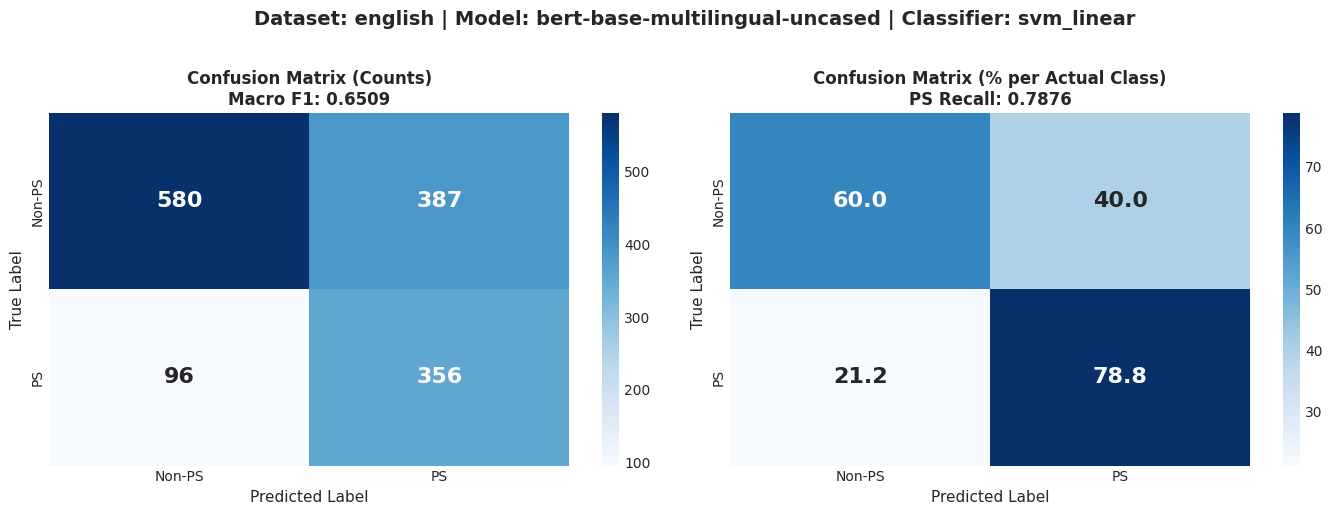


[OK] Saved: confusion_matrix_english_bert_base_multilingual_uncased_svm_rbf.png


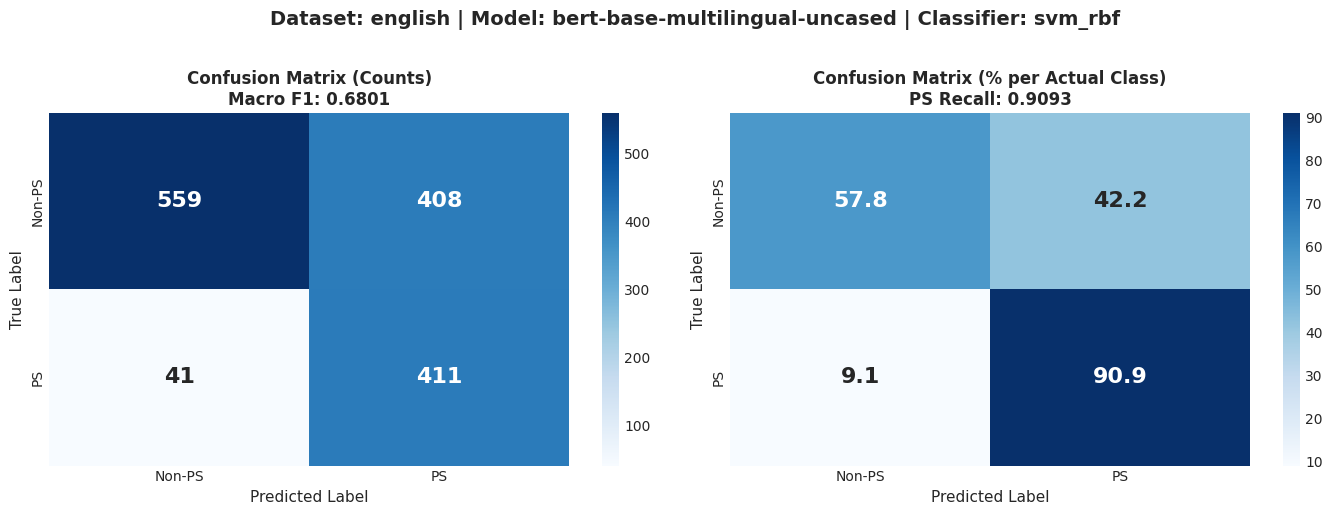


[OK] Saved: confusion_matrix_english_bert_base_multilingual_uncased_random_forest.png


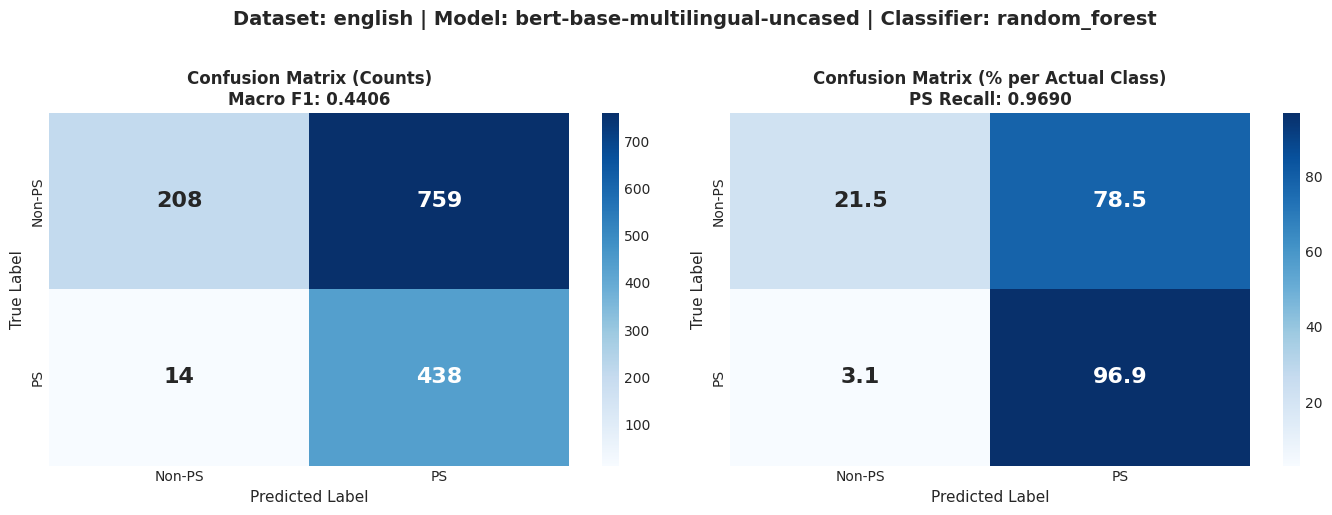


[OK] Saved: confusion_matrix_english_bert_base_multilingual_uncased_xgboost.png


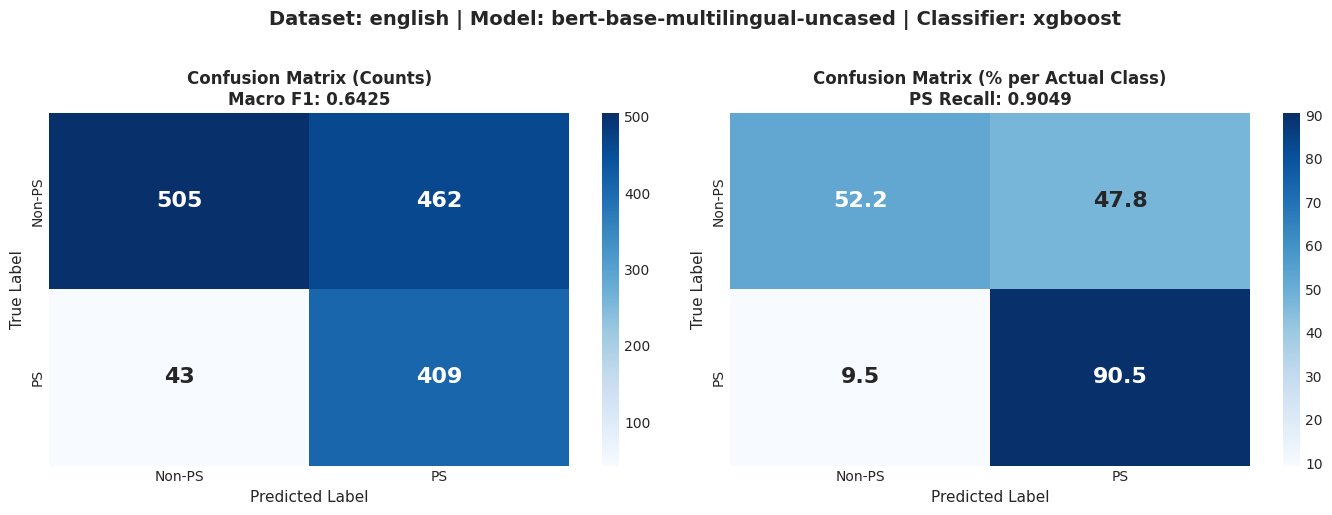


[OK] Saved: confusion_matrix_english_bert_base_multilingual_uncased_lightgbm.png


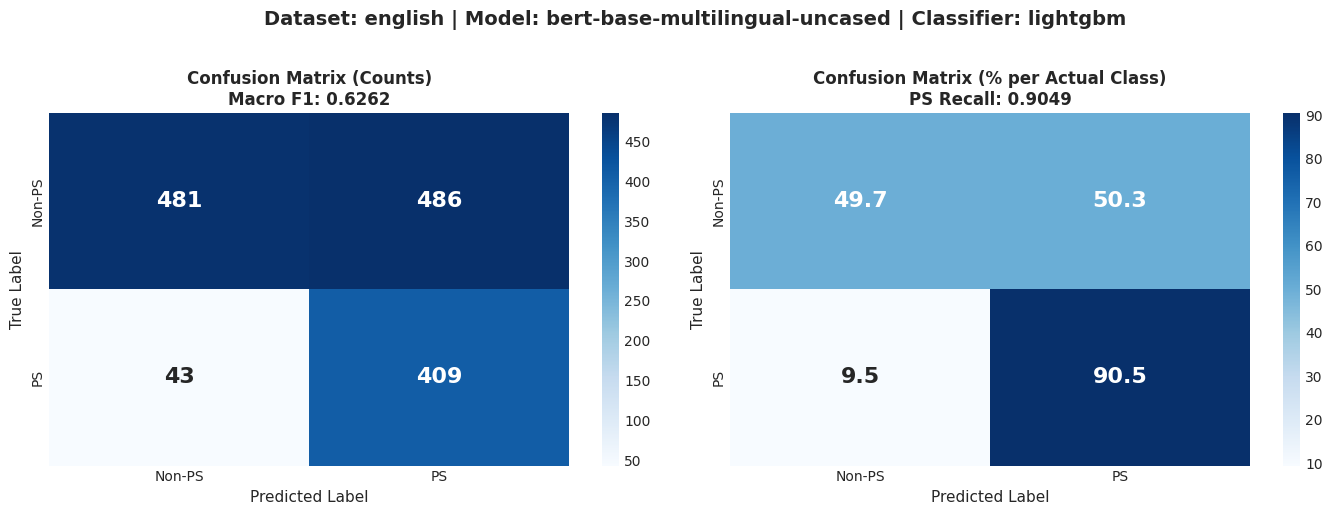


[OK] Saved: confusion_matrix_germany_bert_base_multilingual_uncased_svm_linear.png


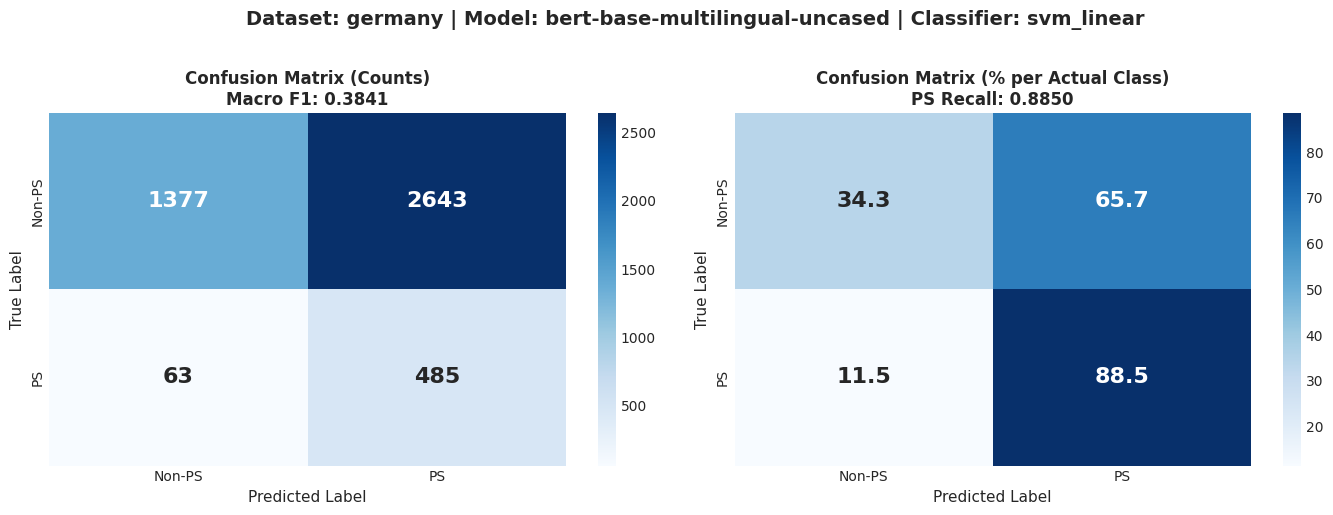

In [ ]:
# ============================================================
# CONFUSION MATRIX VISUALIZATIONS - INDIVIDUAL PLOTS
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns

print("\n" + "#"*80)
print("CONFUSION MATRIX VISUALIZATIONS - EACH CONFIGURATION")
print("#"*80)

# Load results if not already loaded
results_csv = os.path.join(RESULTS_DIR, 'iteration_6_all_results.csv')
if 'results_df' not in dir() or results_df is None:
    if os.path.exists(results_csv):
        results_df = pd.read_csv(results_csv)

if results_df is not None:
    
    # Create individual confusion matrix plots for each configuration
    for idx, row in results_df.iterrows():
        dataset = row['dataset']
        model = row['model']
        classifier = row['classifier']
        
        # Build confusion matrix
        cm = np.array([[int(row['TN']), int(row['FP'])], 
                       [int(row['FN']), int(row['TP'])]])
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Raw counts
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                    xticklabels=['Non-PS', 'PS'], yticklabels=['Non-PS', 'PS'],
                    annot_kws={'size': 16, 'weight': 'bold'})
        axes[0].set_title(f'Confusion Matrix (Counts)\nMacro F1: {row["macro_f1"]:.4f}', 
                          fontsize=12, weight='bold')
        axes[0].set_ylabel('True Label', fontsize=11)
        axes[0].set_xlabel('Predicted Label', fontsize=11)
        
        # Normalized (percentages per actual class)
        cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
        sns.heatmap(cm_norm, annot=True, fmt='.1f', cmap='Blues', ax=axes[1],
                    xticklabels=['Non-PS', 'PS'], yticklabels=['Non-PS', 'PS'],
                    annot_kws={'size': 16, 'weight': 'bold'})
        axes[1].set_title(f'Confusion Matrix (% per Actual Class)\nPS Recall: {row["ps_recall"]:.4f}', 
                          fontsize=12, weight='bold')
        axes[1].set_ylabel('True Label', fontsize=11)
        axes[1].set_xlabel('Predicted Label', fontsize=11)
        
        plt.suptitle(f'Dataset: {dataset} | Model: {model} | Classifier: {classifier}', 
                     fontsize=14, fontweight='bold', y=1.02)
        plt.tight_layout()
        
        # Save individual figure
        safe_name = f"{dataset}_{model}_{classifier}".replace("/", "_").replace("-", "_").replace(" ", "_")
        fig_path = os.path.join(RESULTS_DIR, f'confusion_matrix_{safe_name}.png')
        plt.savefig(fig_path, dpi=150, bbox_inches='tight')
        print(f"\n[OK] Saved: confusion_matrix_{safe_name}.png")
        
        plt.show()
        plt.close()
    
    print(f"\n{'='*80}")
    print("ALL CONFUSION MATRIX VISUALIZATIONS COMPLETE")
    print(f"{'='*80}")
    print(f"\nIndividual confusion matrices saved to: {RESULTS_DIR}")


################################################################################
ITERATION 6: VISUALIZATIONS
################################################################################

Loaded 175 experiment results

Creating comprehensive performance comparison charts...
Comprehensive comparison chart saved to: /home/azureuser/cloudfiles/code/Users/M02555/Results/_iteration_6/iteration_6_performance_comparison.png


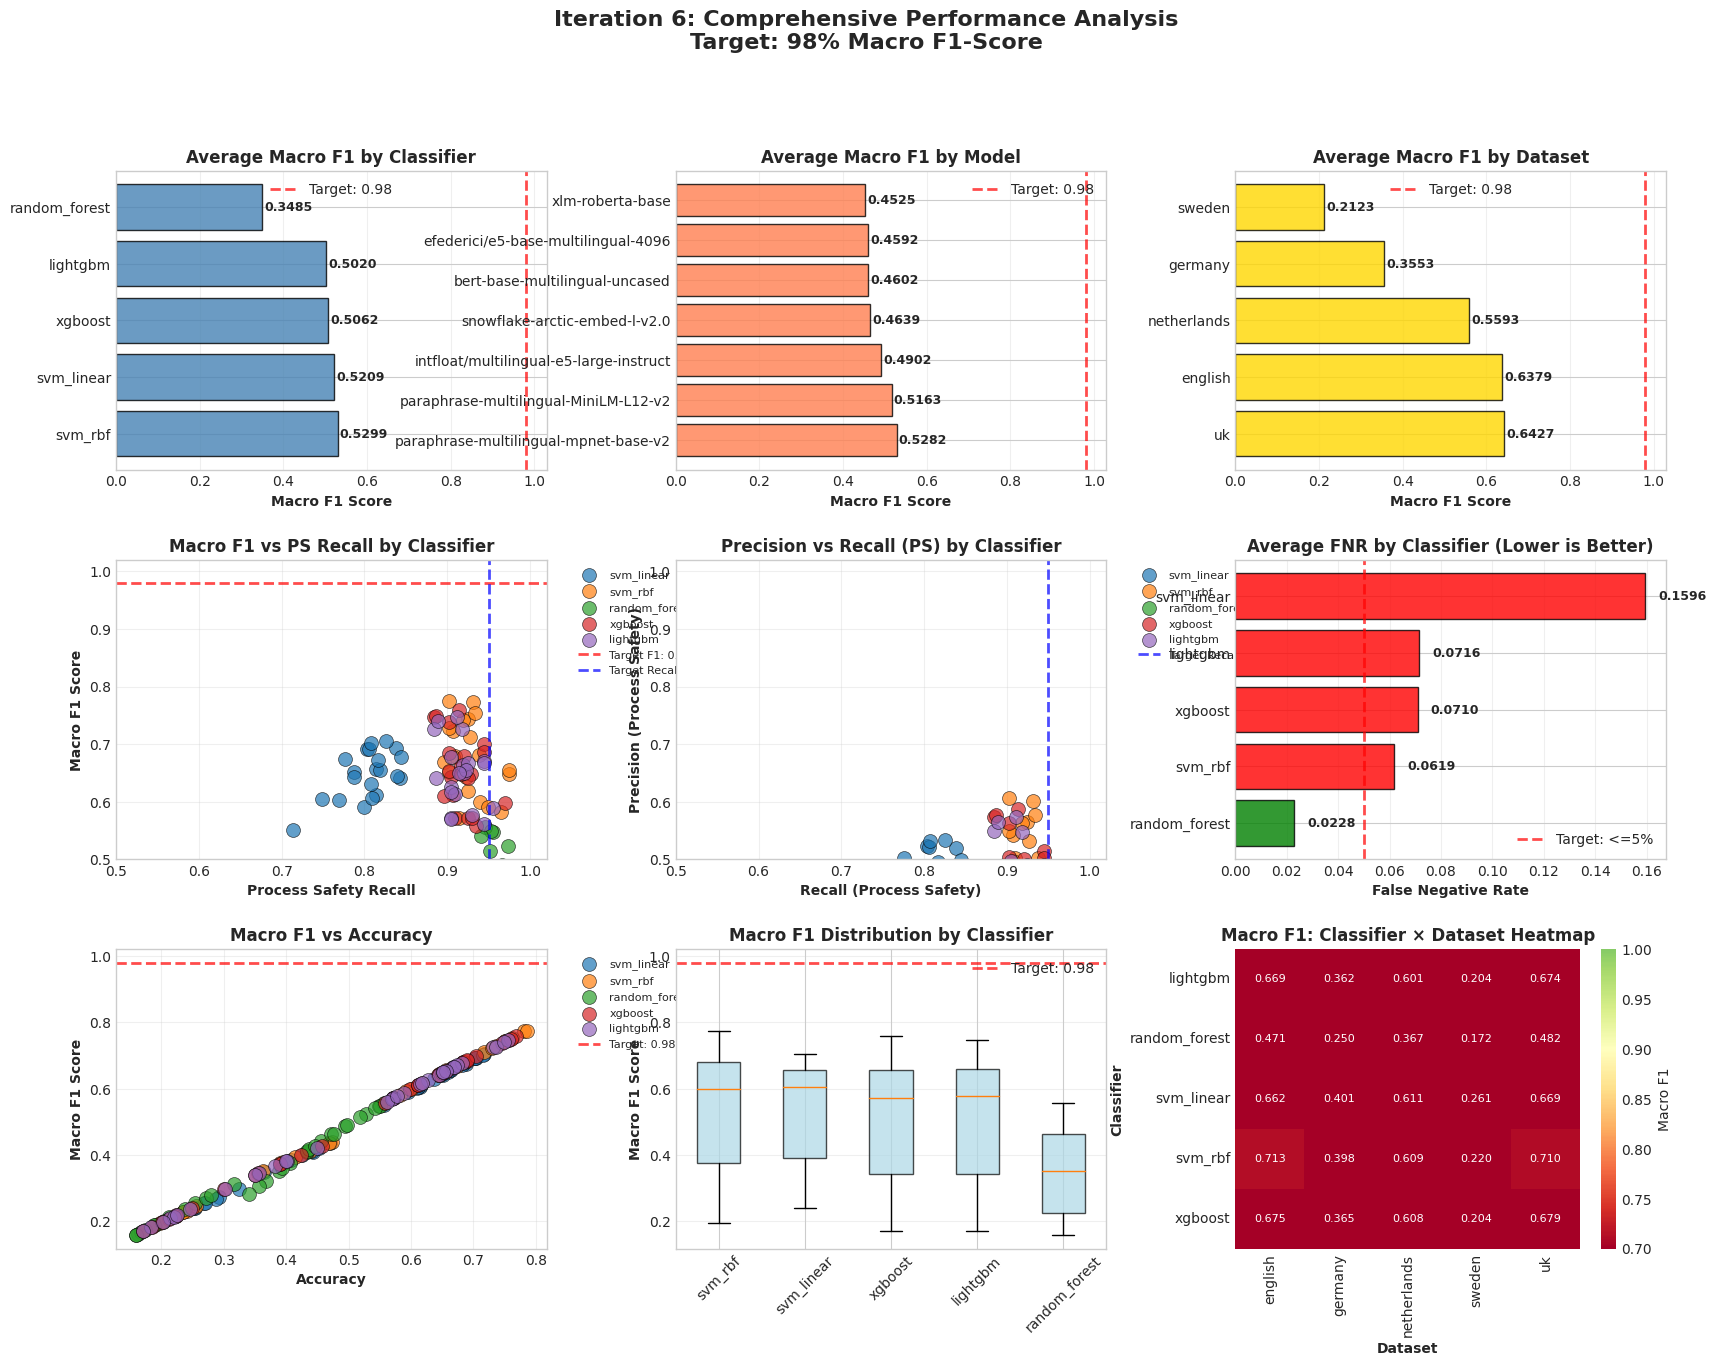

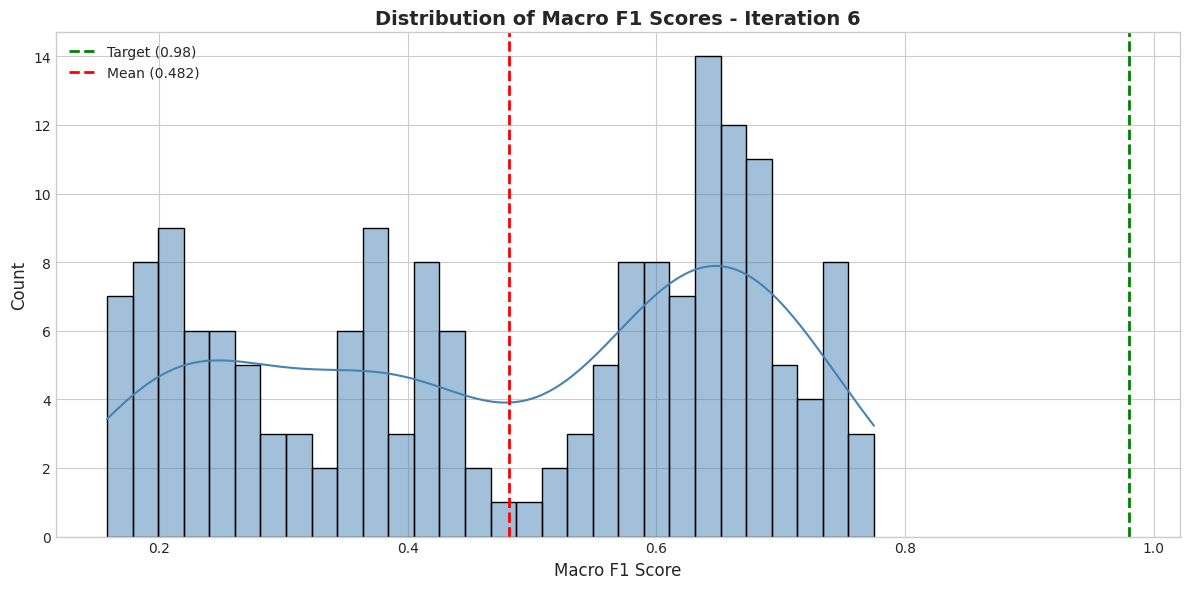

Saved: macro_f1_distribution.png


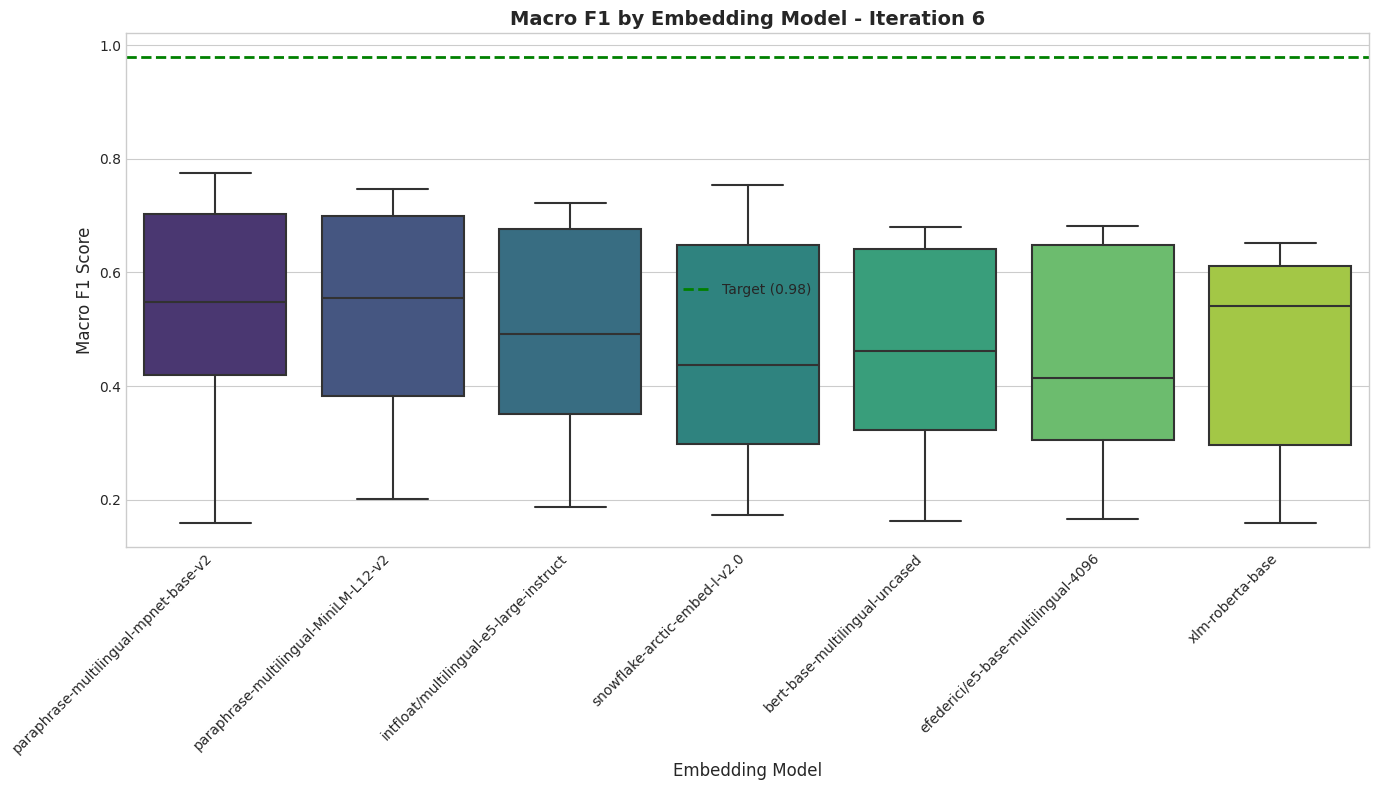

Saved: performance_by_model.png


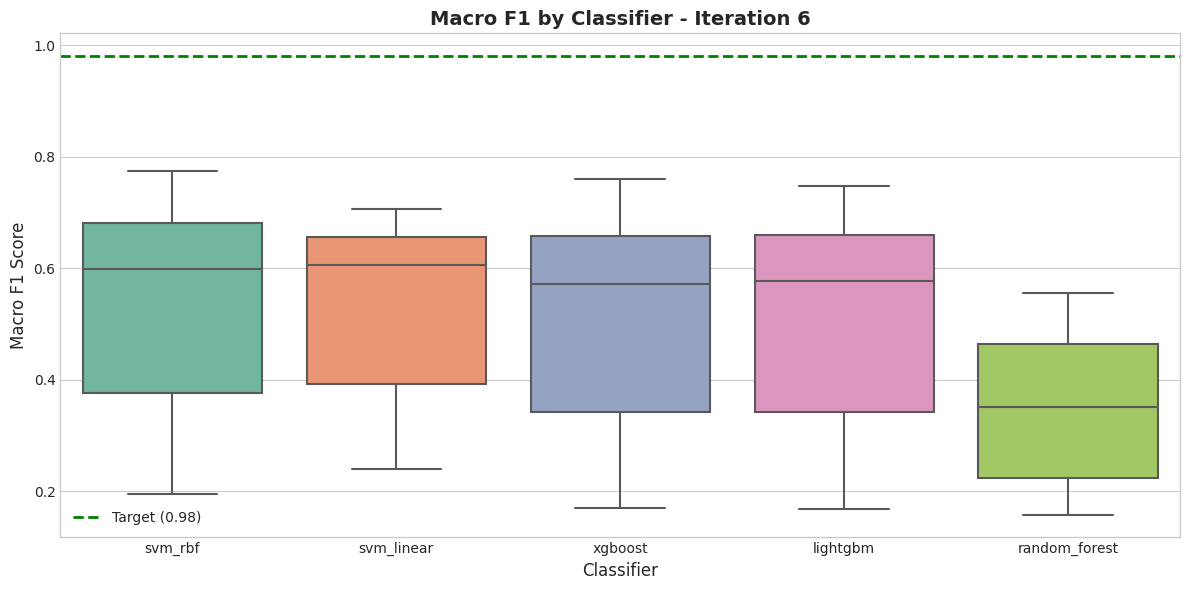

Saved: performance_by_classifier.png


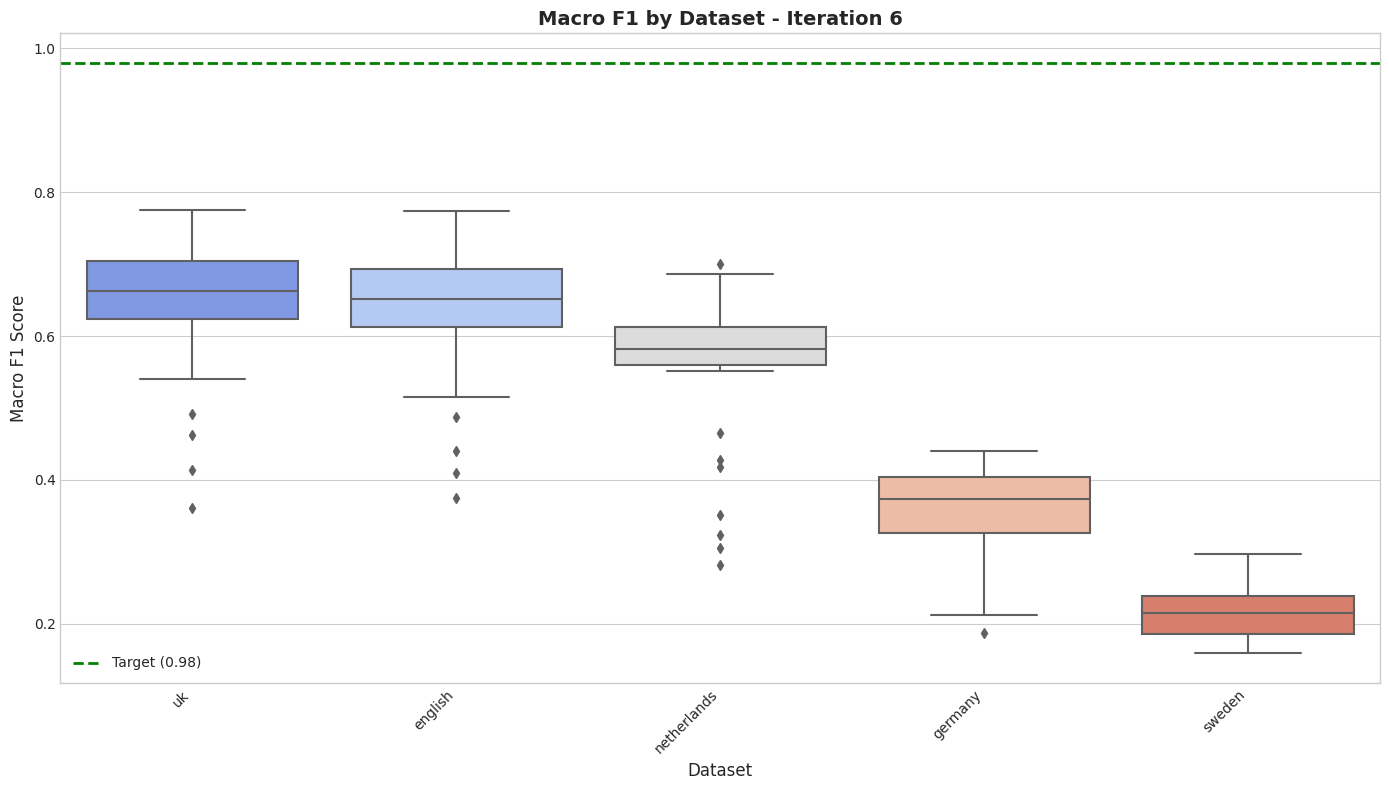

Saved: performance_by_dataset.png


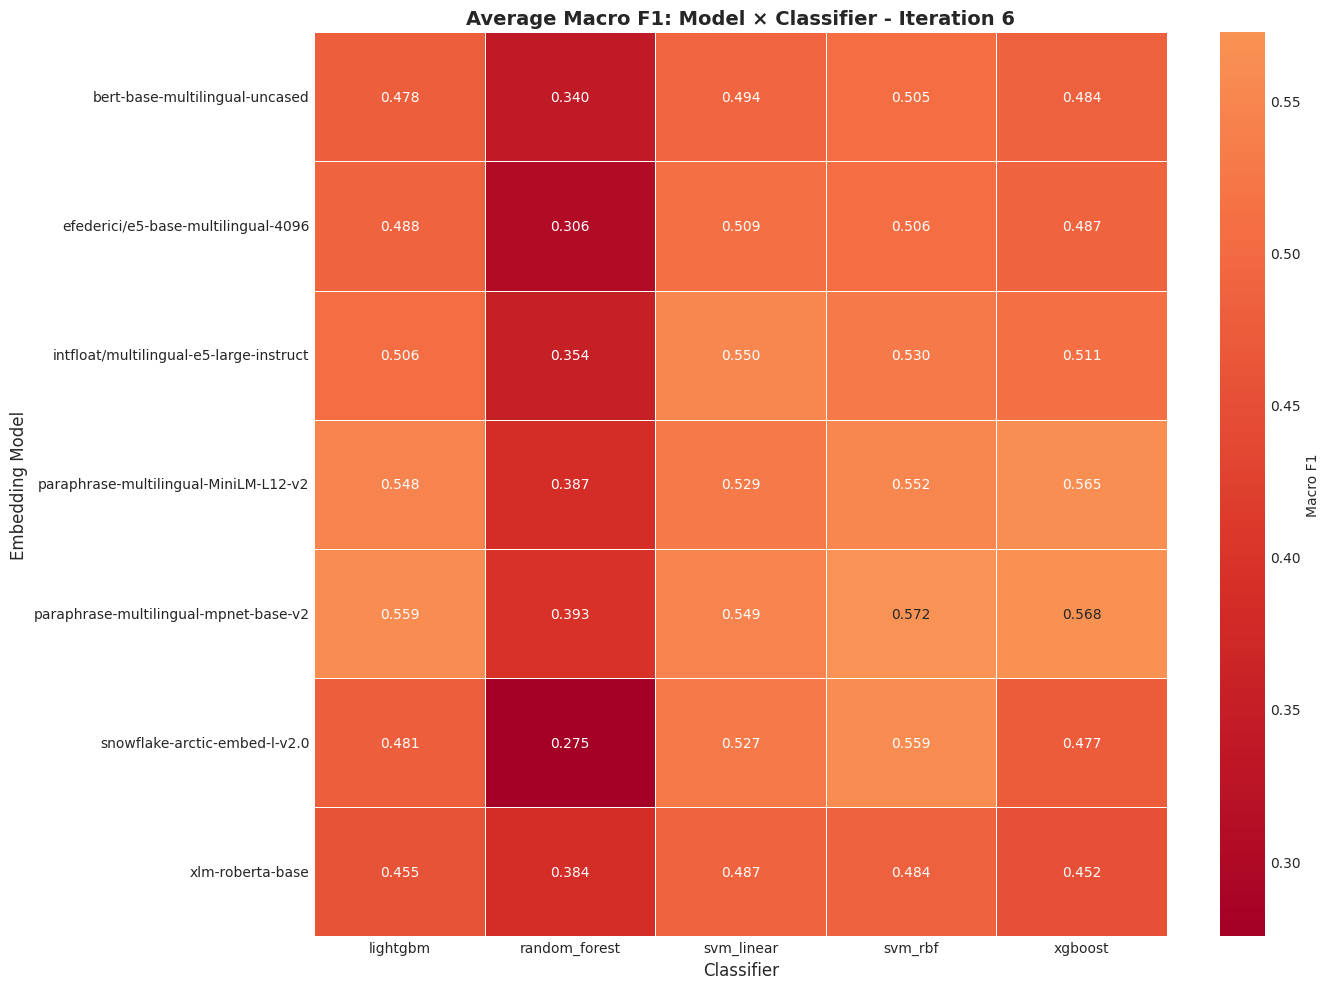

Saved: heatmap_model_classifier.png


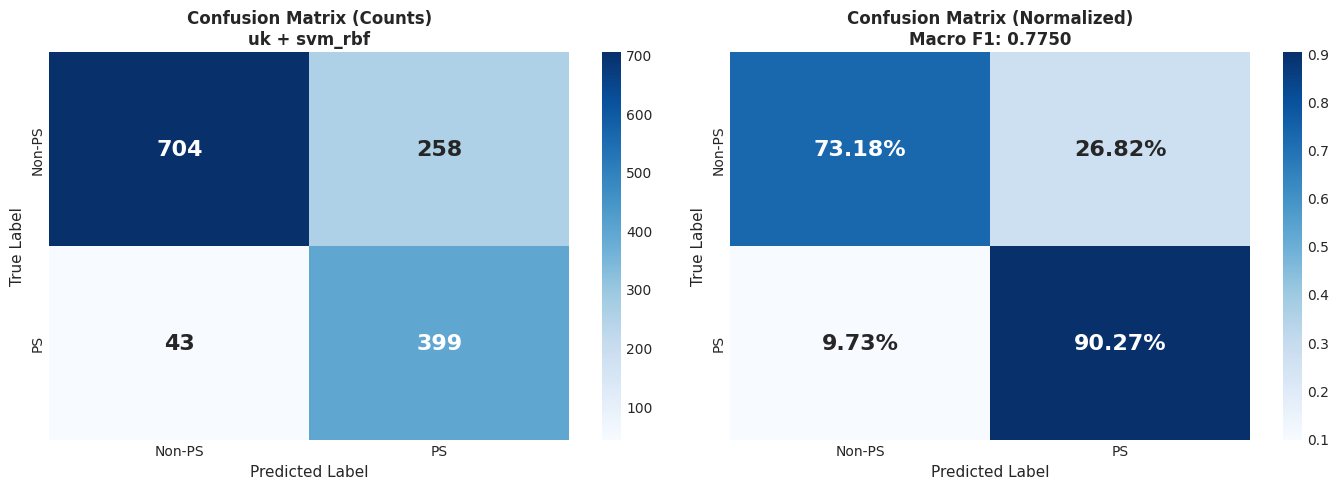

Saved: confusion_matrix_best.png


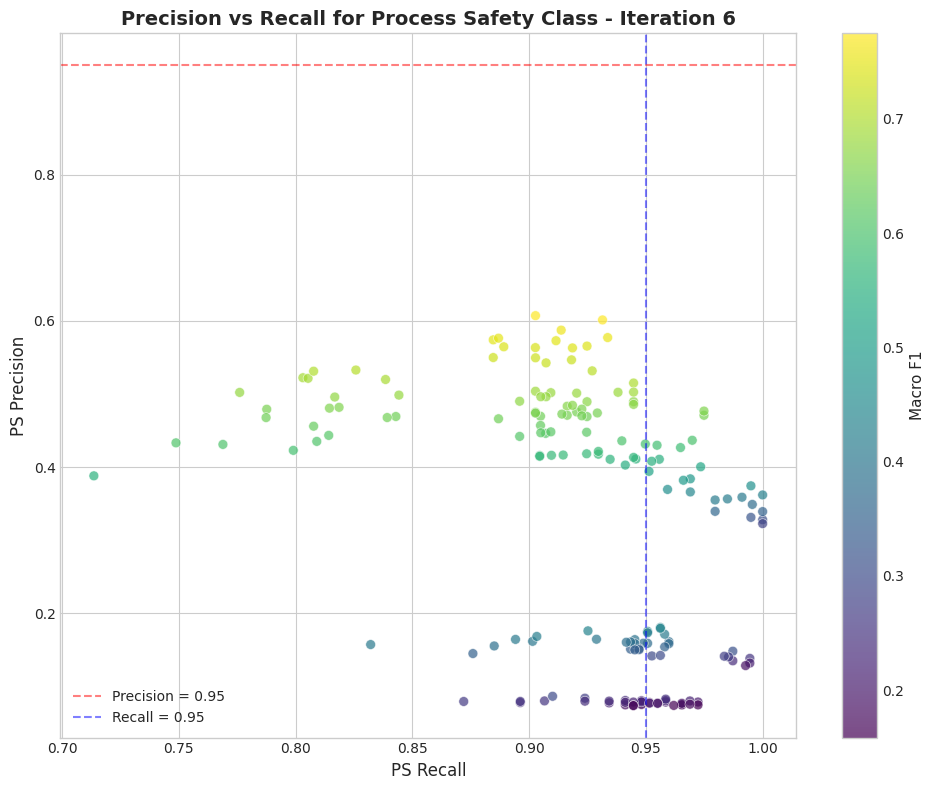

Saved: precision_recall_scatter.png


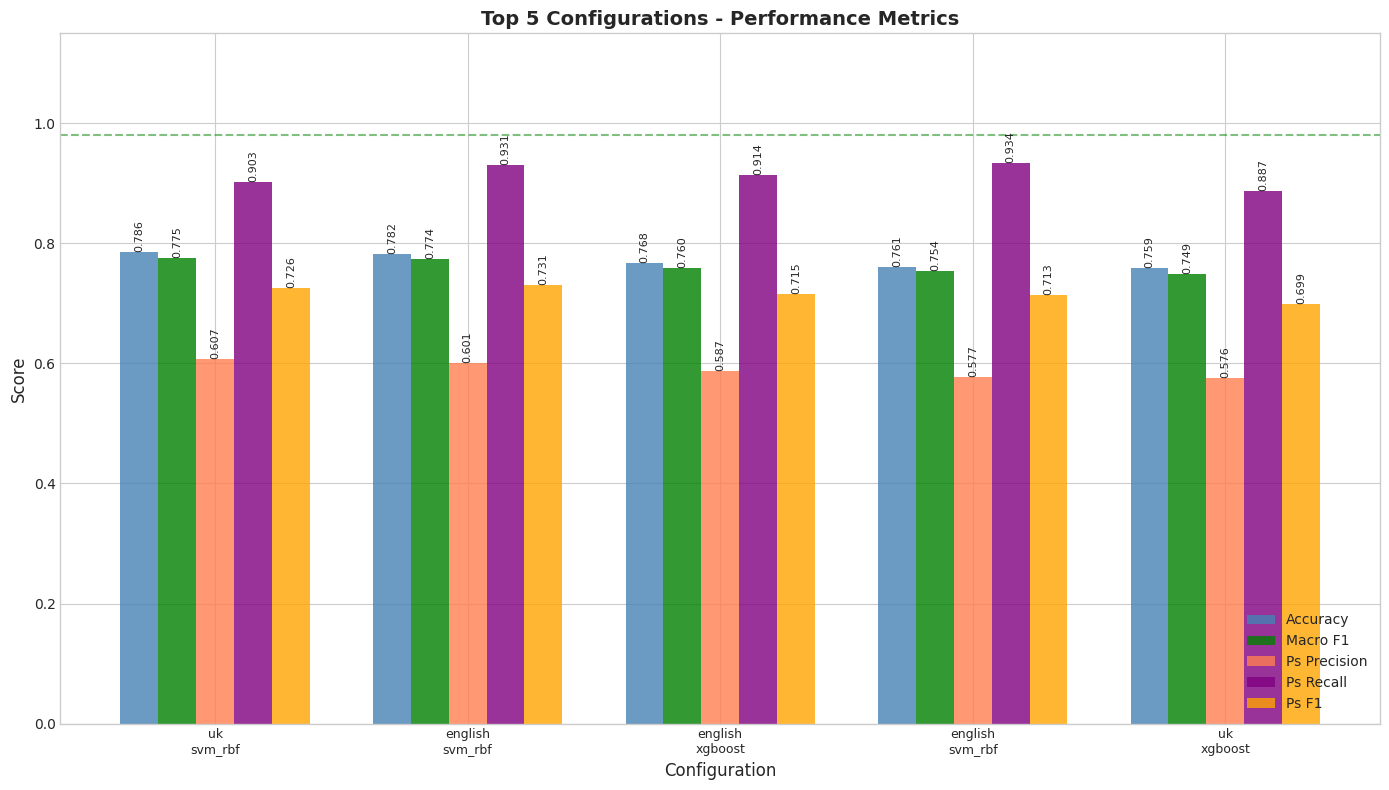

Saved: top5_performance_metrics.png

TARGET ACHIEVEMENT SUMMARY

Combinations meeting 98% Macro F1 target: 0/175 (0.0%)

No combinations met 98% target
   Closest result: 0.7750
   Gap to target: 0.2050

Combinations meeting 95% PS Recall target: 57/175 (32.6%)

VISUALIZATION GENERATION COMPLETE

All visualizations saved to: /home/azureuser/cloudfiles/code/Users/M02555/Results/_iteration_6

Generated files:
   - confusion_matrix_best.png
   - heatmap_model_classifier.png
   - iteration_6_performance_comparison.png
   - macro_f1_distribution.png
   - performance_by_classifier.png
   - performance_by_dataset.png
   - performance_by_model.png
   - precision_recall_scatter.png
   - top5_performance_metrics.png


In [ ]:
# ============================================================
# VISUALIZATION 
# ============================================================
# Note: Imports inherited from Cell 4 (Main Pipeline)

print("\n" + "#"*80)
print("ITERATION 6: VISUALIZATIONS")
print("#"*80)

# Load results
results_csv = os.path.join(RESULTS_DIR, 'iteration_6_all_results.csv')

if os.path.exists(results_csv):
    results_df = pd.read_csv(results_csv)
    print(f"\nLoaded {len(results_df)} experiment results")
else:
    print(f"Results file not found: {results_csv}")
    results_df = None

if results_df is not None:
    
    # Set style
    plt.style.use('seaborn-v0_8-whitegrid')
    
    # ============================================================
    # COMPREHENSIVE 8-PANEL VISUALIZATION
    # ============================================================
    
    print("\nCreating comprehensive performance comparison charts...")
    
    fig = plt.figure(figsize=(20, 14))
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
    
    # 1. Macro F1 by Classifier
    ax1 = fig.add_subplot(gs[0, 0])
    classifier_f1 = results_df.groupby('classifier')['macro_f1'].mean().sort_values(ascending=False)
    bars1 = ax1.barh(classifier_f1.index, classifier_f1.values, color='steelblue', alpha=0.8, edgecolor='navy')
    ax1.set_xlabel('Macro F1 Score', fontweight='bold')
    ax1.set_title('Average Macro F1 by Classifier', fontweight='bold', fontsize=12)
    ax1.axvline(x=0.98, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Target: 0.98')
    ax1.grid(axis='x', alpha=0.3)
    ax1.legend()
    for i, v in enumerate(classifier_f1.values):
        ax1.text(v + 0.005, i, f'{v:.4f}', va='center', fontweight='bold', fontsize=9)
    
    # 2. Macro F1 by Model
    ax2 = fig.add_subplot(gs[0, 1])
    model_f1 = results_df.groupby('model')['macro_f1'].mean().sort_values(ascending=False)
    bars2 = ax2.barh(model_f1.index, model_f1.values, color='royalblue', alpha=0.8, edgecolor='navy')
    ax2.set_xlabel('Macro F1 Score', fontweight='bold')
    ax2.set_title('Average Macro F1 by Model', fontweight='bold', fontsize=12)
    ax2.axvline(x=0.98, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Target: 0.98')
    ax2.grid(axis='x', alpha=0.3)
    ax2.legend()
    for i, v in enumerate(model_f1.values):
        ax2.text(v + 0.005, i, f'{v:.4f}', va='center', fontweight='bold', fontsize=9)
    
    # 3. Macro F1 by Dataset
    ax3 = fig.add_subplot(gs[0, 2])
    dataset_f1 = results_df.groupby('dataset')['macro_f1'].mean().sort_values(ascending=False)
    bars3 = ax3.barh(dataset_f1.index, dataset_f1.values, color='dodgerblue', alpha=0.8, edgecolor='navy')
    ax3.set_xlabel('Macro F1 Score', fontweight='bold')
    ax3.set_title('Average Macro F1 by Dataset', fontweight='bold', fontsize=12)
    ax3.axvline(x=0.98, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Target: 0.98')
    ax3.grid(axis='x', alpha=0.3)
    ax3.legend()
    for i, v in enumerate(dataset_f1.values):
        ax3.text(v + 0.005, i, f'{v:.4f}', va='center', fontweight='bold', fontsize=9)
    
    # 4. Macro F1 vs PS Recall scatter
    ax4 = fig.add_subplot(gs[1, 0])
    scatter4 = ax4.scatter(results_df['ps_recall'], results_df['macro_f1'], 
                           c=results_df['macro_f1'], cmap='Blues', 
                           alpha=0.7, s=100, edgecolors='navy', linewidth=0.5)
    ax4.set_xlabel('Process Safety Recall', fontweight='bold')
    ax4.set_ylabel('Macro F1 Score', fontweight='bold')
    ax4.set_title('Macro F1 vs PS Recall', fontweight='bold', fontsize=12)
    ax4.axhline(y=0.98, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Target F1: 0.98')
    ax4.axvline(x=0.95, color='darkblue', linestyle='--', linewidth=2, alpha=0.7, label='Target Recall: 0.95')
    ax4.legend(fontsize=8)
    ax4.grid(alpha=0.3)
    ax4.set_xlim([0.5, 1.02])
    ax4.set_ylim([0.5, 1.02])
    
    # 5. Precision vs Recall for PS
    ax5 = fig.add_subplot(gs[1, 1])
    scatter5 = ax5.scatter(results_df['ps_recall'], results_df['ps_precision'], 
                           c=results_df['macro_f1'], cmap='Blues', 
                           alpha=0.7, s=100, edgecolors='navy', linewidth=0.5)
    ax5.set_xlabel('Recall (Process Safety)', fontweight='bold')
    ax5.set_ylabel('Precision (Process Safety)', fontweight='bold')
    ax5.set_title('Precision vs Recall (PS)', fontweight='bold', fontsize=12)
    ax5.axvline(x=0.95, color='darkblue', linestyle='--', linewidth=2, alpha=0.7, label='Target Recall: 0.95')
    ax5.legend(fontsize=8)
    ax5.grid(alpha=0.3)
    ax5.set_xlim([0.5, 1.02])
    ax5.set_ylim([0.5, 1.02])
    
    # 6. False Negative Rate Distribution
    ax6 = fig.add_subplot(gs[1, 2])
    if 'FN' in results_df.columns and 'TP' in results_df.columns:
        results_df['FNR'] = results_df['FN'] / (results_df['FN'] + results_df['TP'])
        fnr_data = results_df.groupby('classifier')['FNR'].mean().sort_values()
        bars6 = ax6.barh(fnr_data.index, fnr_data.values, color='cornflowerblue', alpha=0.8, edgecolor='navy')
        ax6.set_xlabel('False Negative Rate', fontweight='bold')
        ax6.set_title('Average FNR by Classifier (Lower is Better)', fontweight='bold', fontsize=12)
        ax6.axvline(x=0.05, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Target: <=5%')
        ax6.grid(axis='x', alpha=0.3)
        ax6.legend()
        for i, v in enumerate(fnr_data.values):
            ax6.text(v + 0.005, i, f'{v:.4f}', va='center', fontweight='bold', fontsize=9)
    else:
        # Alternative: PS F1 by classifier
        ps_f1_data = results_df.groupby('classifier')['ps_f1'].mean().sort_values(ascending=False)
        bars6 = ax6.barh(ps_f1_data.index, ps_f1_data.values, color='cornflowerblue', alpha=0.8, edgecolor='navy')
        ax6.set_xlabel('PS F1 Score', fontweight='bold')
        ax6.set_title('Average PS F1 by Classifier', fontweight='bold', fontsize=12)
        ax6.axvline(x=0.95, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Target: 0.95')
        ax6.grid(axis='x', alpha=0.3)
        ax6.legend()
        for i, v in enumerate(ps_f1_data.values):
            ax6.text(v + 0.005, i, f'{v:.4f}', va='center', fontweight='bold', fontsize=9)
    
    # 7. Macro F1 vs Accuracy scatter
    ax7 = fig.add_subplot(gs[2, 0])
    scatter7 = ax7.scatter(results_df['accuracy'], results_df['macro_f1'], 
                           c=results_df['macro_f1'], cmap='Blues', 
                           alpha=0.7, s=100, edgecolors='navy', linewidth=0.5)
    ax7.set_xlabel('Accuracy', fontweight='bold')
    ax7.set_ylabel('Macro F1 Score', fontweight='bold')
    ax7.set_title('Macro F1 vs Accuracy', fontweight='bold', fontsize=12)
    ax7.axhline(y=0.98, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Target: 0.98')
    ax7.legend(fontsize=8)
    ax7.grid(alpha=0.3)
    
    # 8. Heatmap: Classifier vs Model Performance
    ax8 = fig.add_subplot(gs[2, 1])
    pivot_table_model = results_df.pivot_table(values='macro_f1', index='classifier', columns='model', aggfunc='mean')
    sns.heatmap(pivot_table_model, annot=True, fmt='.3f', cmap='Blues', 
                vmin=0.70, vmax=1.0, ax=ax8, cbar_kws={'label': 'Macro F1'}, annot_kws={'size': 8})
    ax8.set_title('Macro F1: Classifier × Model Heatmap', fontweight='bold', fontsize=12)
    ax8.set_xlabel('Model', fontweight='bold')
    ax8.set_ylabel('Classifier', fontweight='bold')
    
    # 9. Heatmap: Classifier vs Dataset Performance
    ax9 = fig.add_subplot(gs[2, 2])
    pivot_table = results_df.pivot_table(values='macro_f1', index='classifier', columns='dataset', aggfunc='mean')
    sns.heatmap(pivot_table, annot=True, fmt='.3f', cmap='Blues', 
                vmin=0.70, vmax=1.0, ax=ax9, cbar_kws={'label': 'Macro F1'}, annot_kws={'size': 8})
    ax9.set_title('Macro F1: Classifier × Dataset Heatmap', fontweight='bold', fontsize=12)
    ax9.set_xlabel('Dataset', fontweight='bold')
    ax9.set_ylabel('Classifier', fontweight='bold')
    
    plt.suptitle('Iteration 6: Comprehensive Performance Analysis\nTarget: 98% Macro F1-Score', 
                fontsize=16, fontweight='bold', y=0.995)
    
    comparison_plot = os.path.join(RESULTS_DIR, 'iteration_6_performance_comparison.png')
    plt.savefig(comparison_plot, dpi=300, bbox_inches='tight')
    print(f"Comprehensive comparison chart saved to: {comparison_plot}")
    plt.show()
    plt.close()
    
    # ============================================================
    # ADDITIONAL INDIVIDUAL VISUALIZATIONS
    # ============================================================
    
    # 1. MACRO F1 DISTRIBUTION
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.histplot(data=results_df, x='macro_f1', bins=30, kde=True, ax=ax, color='steelblue')
    ax.axvline(x=0.98, color='red', linestyle='--', linewidth=2, label='Target (0.98)')
    ax.axvline(x=results_df['macro_f1'].mean(), color='navy', linestyle='--', linewidth=2, 
               label=f'Mean ({results_df["macro_f1"].mean():.3f})')
    ax.set_xlabel('Macro F1 Score', fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
    ax.set_title('Distribution of Macro F1 Scores - Iteration 6', fontsize=14, weight='bold')
    ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'macro_f1_distribution.png'), dpi=300, bbox_inches='tight')
    plt.show()
    print("Saved: macro_f1_distribution.png")
    
    # 2. PERFORMANCE BY EMBEDDING MODEL (Bar chart instead of boxplot)
    fig, ax = plt.subplots(figsize=(14, 8))
    model_order = results_df.groupby('model')['macro_f1'].mean().sort_values(ascending=False)
    bars = ax.barh(model_order.index, model_order.values, color='royalblue', alpha=0.8, edgecolor='navy')
    ax.axvline(x=0.98, color='red', linestyle='--', linewidth=2, label='Target (0.98)')
    ax.set_xlabel('Average Macro F1 Score', fontsize=12)
    ax.set_ylabel('Embedding Model', fontsize=12)
    ax.set_title('Average Macro F1 by Embedding Model - Iteration 6', fontsize=14, weight='bold')
    ax.legend()
    for i, v in enumerate(model_order.values):
        ax.text(v + 0.005, i, f'{v:.4f}', va='center', fontweight='bold', fontsize=9)
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'performance_by_model.png'), dpi=300, bbox_inches='tight')
    plt.show()
    print("Saved: performance_by_model.png")
    
    # 3. PERFORMANCE BY CLASSIFIER (Bar chart instead of boxplot)
    fig, ax = plt.subplots(figsize=(12, 6))
    clf_order = results_df.groupby('classifier')['macro_f1'].mean().sort_values(ascending=False)
    bars = ax.barh(clf_order.index, clf_order.values, color='steelblue', alpha=0.8, edgecolor='navy')
    ax.axvline(x=0.98, color='red', linestyle='--', linewidth=2, label='Target (0.98)')
    ax.set_xlabel('Average Macro F1 Score', fontsize=12)
    ax.set_ylabel('Classifier', fontsize=12)
    ax.set_title('Average Macro F1 by Classifier - Iteration 6', fontsize=14, weight='bold')
    ax.legend()
    for i, v in enumerate(clf_order.values):
        ax.text(v + 0.005, i, f'{v:.4f}', va='center', fontweight='bold', fontsize=9)
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'performance_by_classifier.png'), dpi=300, bbox_inches='tight')
    plt.show()
    print("Saved: performance_by_classifier.png")
    
    # 4. PERFORMANCE BY DATASET (Bar chart instead of boxplot)
    fig, ax = plt.subplots(figsize=(14, 8))
    dataset_order = results_df.groupby('dataset')['macro_f1'].mean().sort_values(ascending=False)
    bars = ax.barh(dataset_order.index, dataset_order.values, color='dodgerblue', alpha=0.8, edgecolor='navy')
    ax.axvline(x=0.98, color='red', linestyle='--', linewidth=2, label='Target (0.98)')
    ax.set_xlabel('Average Macro F1 Score', fontsize=12)
    ax.set_ylabel('Dataset', fontsize=12)
    ax.set_title('Average Macro F1 by Dataset - Iteration 6', fontsize=14, weight='bold')
    ax.legend()
    for i, v in enumerate(dataset_order.values):
        ax.text(v + 0.005, i, f'{v:.4f}', va='center', fontweight='bold', fontsize=9)
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'performance_by_dataset.png'), dpi=300, bbox_inches='tight')
    plt.show()
    print("Saved: performance_by_dataset.png")
    
    # 5. HEATMAP: MODEL x CLASSIFIER
    fig, ax = plt.subplots(figsize=(14, 10))
    pivot_df = results_df.pivot_table(values='macro_f1', index='model', columns='classifier', aggfunc='mean')
    sns.heatmap(pivot_df, annot=True, fmt='.3f', cmap='Blues', 
                ax=ax, linewidths=0.5, cbar_kws={'label': 'Macro F1'})
    ax.set_title('Average Macro F1: Model × Classifier - Iteration 6', fontsize=14, weight='bold')
    ax.set_xlabel('Classifier', fontsize=12)
    ax.set_ylabel('Embedding Model', fontsize=12)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'heatmap_model_classifier.png'), dpi=300, bbox_inches='tight')
    plt.show()
    print("Saved: heatmap_model_classifier.png")
    
    # 6. CONFUSION MATRIX - BEST MODEL
    best_idx = results_df['macro_f1'].idxmax()
    best_row = results_df.loc[best_idx]
    
    cm = np.array([[best_row['TN'], best_row['FP']], 
                   [best_row['FN'], best_row['TP']]])
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Raw counts
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Non-PS', 'PS'], yticklabels=['Non-PS', 'PS'],
                annot_kws={'size': 16, 'weight': 'bold'})
    axes[0].set_title(f'Confusion Matrix (Counts)\n{best_row["dataset"]} + {best_row["classifier"]}', 
                      fontsize=12, weight='bold')
    axes[0].set_ylabel('True Label', fontsize=11)
    axes[0].set_xlabel('Predicted Label', fontsize=11)
    
    # Normalized
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
                xticklabels=['Non-PS', 'PS'], yticklabels=['Non-PS', 'PS'],
                annot_kws={'size': 16, 'weight': 'bold'})
    axes[1].set_title(f'Confusion Matrix (Normalized)\nMacro F1: {best_row["macro_f1"]:.4f}', 
                      fontsize=12, weight='bold')
    axes[1].set_ylabel('True Label', fontsize=11)
    axes[1].set_xlabel('Predicted Label', fontsize=11)
    
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'confusion_matrix_best.png'), dpi=300, bbox_inches='tight')
    plt.show()
    print("Saved: confusion_matrix_best.png")
    
    # 7. PRECISION VS RECALL SCATTER
    fig, ax = plt.subplots(figsize=(10, 8))
    scatter = ax.scatter(results_df['ps_recall'], results_df['ps_precision'], 
                         c=results_df['macro_f1'], cmap='Blues', 
                         alpha=0.7, s=50, edgecolors='navy', linewidth=0.5)
    ax.axhline(y=0.95, color='red', linestyle='--', alpha=0.5, label='Precision = 0.95')
    ax.axvline(x=0.95, color='darkblue', linestyle='--', alpha=0.5, label='Recall = 0.95')
    ax.set_xlabel('PS Recall', fontsize=12)
    ax.set_ylabel('PS Precision', fontsize=12)
    ax.set_title('Precision vs Recall for Process Safety Class - Iteration 6', fontsize=14, weight='bold')
    ax.legend(loc='lower left')
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Macro F1', fontsize=11)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'precision_recall_scatter.png'), dpi=300, bbox_inches='tight')
    plt.show()
    print("Saved: precision_recall_scatter.png")
    
    # 8. PERFORMANCE METRICS BAR CHART - TOP 5
    fig, ax = plt.subplots(figsize=(14, 8))
    top_5 = results_df.nlargest(5, 'macro_f1')
    top_5['config'] = top_5['dataset'] + '\n' + top_5['classifier']
    metrics = ['accuracy', 'macro_f1', 'ps_precision', 'ps_recall', 'ps_f1']
    x = np.arange(len(top_5))
    width = 0.15
    blue_shades = ['#08306b', '#2171b5', '#4292c6', '#6baed6', '#9ecae1']
    
    for i, metric in enumerate(metrics):
        bars = ax.bar(x + i * width, top_5[metric], width, label=metric.replace('_', ' ').title(), 
                      color=blue_shades[i], alpha=0.9)
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=8, rotation=90)
    
    ax.set_xlabel('Configuration', fontsize=12)
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title('Top 5 Configurations - Performance Metrics', fontsize=14, weight='bold')
    ax.set_xticks(x + width * 2)
    ax.set_xticklabels(top_5['config'], rotation=0, ha='center', fontsize=9)
    ax.legend(loc='lower right')
    ax.set_ylim(0, 1.15)
    ax.axhline(y=0.98, color='red', linestyle='--', alpha=0.5, label='Target')
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'top5_performance_metrics.png'), dpi=300, bbox_inches='tight')
    plt.show()
    print("Saved: top5_performance_metrics.png")
    
    # ============================================================
    # TARGET ACHIEVEMENT SUMMARY
    # ============================================================
    print(f"\n{'='*80}")
    print("TARGET ACHIEVEMENT SUMMARY")
    print(f"{'='*80}")
    
    # Count combinations meeting 98% target
    meets_98 = results_df[results_df['macro_f1'] >= 0.98]
    print(f"\nCombinations meeting 98% Macro F1 target: {len(meets_98)}/{len(results_df)} ({len(meets_98)/len(results_df)*100:.1f}%)")
    
    if len(meets_98) > 0:
        print(f"\nSUCCESS! Target achieved by:")
        print(meets_98[['dataset', 'model', 'classifier', 'macro_f1', 'ps_f1', 'ps_recall']].to_string(index=False))
    else:
        print(f"\nNo combinations met 98% target")
        print(f"   Closest result: {results_df['macro_f1'].max():.4f}")
        print(f"   Gap to target: {0.98 - results_df['macro_f1'].max():.4f}")
    
    # Count combinations meeting 95% PS recall target
    meets_recall = results_df[results_df['ps_recall'] >= 0.95]
    print(f"\nCombinations meeting 95% PS Recall target: {len(meets_recall)}/{len(results_df)} ({len(meets_recall)/len(results_df)*100:.1f}%)")
    
    print(f"\n{'='*80}")
    print("VISUALIZATION GENERATION COMPLETE")
    print(f"{'='*80}")
    print(f"\nAll visualizations saved to: {RESULTS_DIR}")
    print("\nGenerated files:")
    for f in sorted(os.listdir(RESULTS_DIR)):
        if f.endswith('.png'):
            print(f"   - {f}")

In [8]:
# ============================================================
# FINAL RESULTS REVIEW
# ============================================================
# Note: Imports inherited from Cell 4 (Main Pipeline)

print("\n" + "#"*80)
print("ITERATION 6: FINAL RESULTS REVIEW")
print("#"*80)

# List all files in results directory
print(f"\nResults directory: {RESULTS_DIR}")
print(f"\nContents:")
for f in sorted(os.listdir(RESULTS_DIR)):
    size = os.path.getsize(os.path.join(RESULTS_DIR, f))
    if size > 1024*1024:
        print(f"   {f}: {size/1024/1024:.2f} MB")
    elif size > 1024:
        print(f"   {f}: {size/1024:.2f} KB")
    else:
        print(f"   {f}: {size} bytes")

# Load and display final summary
results_csv = os.path.join(RESULTS_DIR, 'iteration_6_all_results.csv')
if os.path.exists(results_csv):
    results_df = pd.read_csv(results_csv)
    
    print(f"\n{'='*80}")
    print("ITERATION 6 - FINAL SUMMARY")
    print(f"{'='*80}")
    
    print(f"\n EXPERIMENT STATISTICS:")
    print(f"   Total experiments: {len(results_df)}")
    print(f"   Datasets tested: {results_df['dataset'].nunique()}")
    print(f"   Embedding models: {results_df['model'].nunique()}")
    print(f"   Classifiers: {results_df['classifier'].nunique()}")
    
    print(f"\n PERFORMANCE METRICS:")
    print(f"   Best Macro F1:    {results_df['macro_f1'].max():.4f}")
    print(f"   Mean Macro F1:    {results_df['macro_f1'].mean():.4f}")
    print(f"   Best PS Recall:   {results_df['ps_recall'].max():.4f}")
    print(f"   Best Accuracy:    {results_df['accuracy'].max():.4f}")
    
    # Target achievement
    target_f1 = 0.98
    achieved = len(results_df[results_df['macro_f1'] >= target_f1])
    print(f"\n TARGET ACHIEVEMENT (Macro F1 >= {target_f1}):")
    print(f"   Achieved: {achieved}/{len(results_df)} ({achieved/len(results_df)*100:.1f}%)")
    
    if achieved > 0:
        print(f"\n   Configurations achieving target:")
        top_achievers = results_df[results_df['macro_f1'] >= target_f1].nlargest(5, 'macro_f1')
        for _, row in top_achievers.iterrows():
            print(f"      - {row['dataset']} + {row['model'][:30]} + {row['classifier']}")
            print(f"        Macro F1: {row['macro_f1']:.4f}, PS Recall: {row['ps_recall']:.4f}")
    
    # Best overall
    best = results_df.loc[results_df['macro_f1'].idxmax()]
    print(f"\n BEST OVERALL CONFIGURATION:")
    print(f"   Dataset:     {best['dataset']}")
    print(f"   Model:       {best['model']}")
    print(f"   Classifier:  {best['classifier']}")
    print(f"   Macro F1:    {best['macro_f1']:.4f}")
    print(f"   PS Recall:   {best['ps_recall']:.4f}")
    print(f"   PS Precision:{best['ps_precision']:.4f}")
    print(f"   Accuracy:    {best['accuracy']:.4f}")
    
    # Pipeline complete banner (matching Iteration 3 format)
    print("\n")
    print("#" * 80)
    print(" ITERATION 6 PIPELINE COMPLETE")
    print("#" * 80)

    
else:
    print(f"\nResults file not found. Please run the training pipeline first.")


################################################################################
ITERATION 6: FINAL RESULTS REVIEW
################################################################################

Results directory: /home/azureuser/cloudfiles/code/Users/M02555/Results/_iteration_6

Contents:
   confusion_matrix_best.png: 169.02 KB
   heatmap_model_classifier.png: 339.90 KB
   iteration_6_all_results.csv: 47.56 KB
   iteration_6_performance_comparison.png: 1.20 MB
   iteration_6_summary.txt: 310 bytes
   macro_f1_distribution.png: 139.95 KB
   performance_by_classifier.png: 103.94 KB
   performance_by_dataset.png: 150.83 KB
   performance_by_model.png: 331.11 KB
   precision_recall_scatter.png: 277.70 KB
   top5_performance_metrics.png: 205.03 KB

ITERATION 6 - FINAL SUMMARY

 EXPERIMENT STATISTICS:
   Total experiments: 175
   Datasets tested: 5
   Embedding models: 7
   Classifiers: 5

 PERFORMANCE METRICS:
   Best Macro F1:    0.7750
   Mean Macro F1:    0.4815
   Best PS Recall:   